# 1. THU THẬP VÀ TIỀN XỬ LÝ DỮ LIỆU
## 1.1. Khai báo thư viện và đọc dữ liệu
Dữ liệu được thu thập từ bộ dữ liệu của Cottom et al. và được công bố cùng nghiên cứu về phát thải rác thải nhựa toàn cầu.
Trong bước này, dữ liệu gốc được giữ nguyên và đọc vào Python bằng thư viện Pandas. File dữ liệu chứa một số dòng metadata mô tả nguồn, đơn vị đo, năm dữ liệu và tỷ lệ dữ liệu thiếu. Do đó, dòng chứa tên biến thực tế được xác định bằng tham số `header=5`.
Dữ liệu gốc được lưu trong biến `df_raw` và không được chỉnh sửa trực tiếp nhằm phục vụ việc so sánh trước và sau tiền xử lý.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

current_dir = Path.cwd().resolve()

PROJECT_DIR = None

for folder in [current_dir, *current_dir.parents]:
    if (folder / "data" / "raw").exists():
        PROJECT_DIR = folder
        break

if PROJECT_DIR is None:
    raise FileNotFoundError(
        "Không xác định được thư mục gốc dự án. "
        "Hãy mở VS Code tại thư mục dự án trước khi chạy notebook."
    )

RAW_DIR = PROJECT_DIR / "data" / "raw"
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
FIGURES_DIR = PROJECT_DIR / "figures"

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_DIR:", PROJECT_DIR)
print("RAW_DIR:", RAW_DIR)
print("PROCESSED_DIR:", PROCESSED_DIR)
print("FIGURES_DIR:", FIGURES_DIR)

PROJECT_DIR: D:\tương tác dữ liệu trực quan\đồ án cuối kỳ
RAW_DIR: D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\raw
PROCESSED_DIR: D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\processed
FIGURES_DIR: D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\figures


In [2]:
file_path = RAW_DIR / "Global_Municipalities_for_imputation.xlsx"

if not file_path.exists():
    raise FileNotFoundError(f"Không tìm thấy file: {file_path}")

print("Đã tìm thấy file dữ liệu:")
print(file_path)

Đã tìm thấy file dữ liệu:
D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\raw\Global_Municipalities_for_imputation.xlsx


In [3]:
sheet_name = "Indep. Var - Numeric for imp."

df_raw = pd.read_excel(
    file_path,
    sheet_name=sheet_name,
    header=5
)

print("Kích thước dữ liệu:", df_raw.shape)

Kích thước dữ liệu: (50702, 30)


## 1.2. Khảo sát cấu trúc dữ liệu ban đầu
Trước khi tiến hành làm sạch, nhóm thực hiện khảo sát cấu trúc của tập dữ liệu nhằm xác định số lượng bản ghi, số lượng thuộc tính, kiểu dữ liệu và một số bản ghi mẫu.
Bước này giúp đánh giá sơ bộ chất lượng dữ liệu và là cơ sở để xây dựng quy trình tiền xử lý phù hợp.

In [4]:
print("Kích thước dữ liệu:", df_raw.shape)
print("Số dòng:", df_raw.shape[0])
print("Số cột:", df_raw.shape[1])

display(df_raw.head())

Kích thước dữ liệu: (50702, 30)
Số dòng: 50702
Số cột: 30


,UniqueID,ISO3,Country,Name_1,Name_2,Name_3,Name_4,Population,Urban_centre_share,Urban_cluster_share,Rural_share,DEGURBA_L1,DEGURBA_L2,Area,Population_density,GDP_PerCapita_PPP,HDI,Captal_city,World_city,Mega_city,Major_city,Income_level,Developing_country,Small_island_developing_state,Region,Sub_region,International_annual_tourists,Corruption_perception_index,Social_progress_index,GNI_per_capita
0,ABW,ABW,Aruba,NaN,NaN,NaN,NaN,"104,171.35",0.52,0.43,0.05,3,30,183.05,569.09,"25,314.40",0.83,0,0,0,0,4.00,1,1,19,419,"1,758.64",NaN,NaN,"26,180.00"
1,AFG.1.1_1,AFG,Afghanistan,Badakhshan,Baharak,NaN,NaN,"130,437.64",0.00,0.76,0.24,2,23,"3,009.47",43.34,"1,820.30",0.48,0,0,0,0,1.00,1,0,142,34,NaN,11.00,36.58,610.00
2,AFG.1.2_1,AFG,Afghanistan,Badakhshan,Darwaz,NaN,NaN,"92,093.48",0.00,0.60,0.40,2,23,"2,925.25",31.48,"1,820.30",0.49,0,0,0,0,1.00,1,0,142,34,NaN,11.00,36.58,610.00
3,AFG.1.3_1,AFG,Afghanistan,Badakhshan,Fayzabad,NaN,NaN,"373,891.21",0.57,0.30,0.13,3,30,"2,945.13",126.95,"1,820.30",0.48,0,0,0,0,1.00,1,0,142,34,NaN,11.00,36.58,610.00
4,AFG.1.4_1,AFG,Afghanistan,Badakhshan,Ishkashim,NaN,NaN,"20,674.25",0.00,0.33,0.67,1,12,"1,572.40",13.15,"1,820.30",0.48,0,0,0,0,1.00,1,0,142,34,NaN,11.00,36.58,610.00


### 1.2.1. Danh sách thuộc tính và kiểu dữ liệu
Nhóm kiểm tra tên các thuộc tính, kiểu dữ liệu và số lượng giá trị không thiếu của từng biến nhằm xác định các biến định danh, biến phân loại và biến số.
Việc xác định đúng kiểu dữ liệu là cần thiết trước khi xử lý giá trị thiếu, phát hiện ngoại lai và xây dựng các phép biến đổi dữ liệu.

In [5]:
print("Danh sách các thuộc tính:\n")

for i, col in enumerate(df_raw.columns, start=1):
    print(f"{i}. {col}")
df_raw.info()

Danh sách các thuộc tính:

1. UniqueID
2. ISO3
3. Country
4. Name_1
5. Name_2
6. Name_3
7. Name_4
8. Population
9. Urban_centre_share
10. Urban_cluster_share
11. Rural_share
12. DEGURBA_L1
13. DEGURBA_L2
14. Area
15. Population_density
16. GDP_PerCapita_PPP
17. HDI
18. Captal_city
19. World_city
20. Mega_city
21. Major_city
22. Income_level
23. Developing_country
24. Small_island_developing_state
25. Region
26. Sub_region
27. International_annual_tourists
28. Corruption_perception_index
29. Social_progress_index
30. GNI_per_capita
<class 'pandas.DataFrame'>
RangeIndex: 50702 entries, 0 to 50701
Data columns (total 30 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   UniqueID                       50702 non-null  str    
 1   ISO3                           50702 non-null  str    
 2   Country                        50702 non-null  str    
 3   Name_1                         50671 non-null  str    
 4   

In [6]:
dtype_summary = pd.DataFrame({
    "Column": df_raw.columns,
    "Data_Type": df_raw.dtypes.astype(str),
    "Non_Null": df_raw.notna().sum(),
    "Missing": df_raw.isna().sum()
})

display(dtype_summary)

,Column,Data_Type,Non_Null,Missing
UniqueID,UniqueID,str,50702,0
ISO3,ISO3,str,50702,0
Country,Country,str,50702,0
Name_1,Name_1,str,50671,31
Name_2,Name_2,str,49435,1267
Name_3,Name_3,str,14212,36490
Name_4,Name_4,str,4361,46341
Population,Population,float64,50702,0
Urban_centre_share,Urban_centre_share,float64,50702,0
Urban_cluster_share,Urban_cluster_share,float64,50702,0


## 1.3. Đánh giá chất lượng dữ liệu trước tiền xử lý
Trước khi làm sạch, nhóm tiến hành đánh giá tập dữ liệu theo các tiêu chí:
- Khóa định danh có bị thiếu hoặc trùng lặp hay không.
- Có tồn tại bản ghi trùng lặp hoàn toàn hay không.
- Mức độ thiếu dữ liệu của từng thuộc tính.
- Phạm vi và phân phối của các biến số.
- Các giá trị ngoại lai tiềm năng.
Các kết quả tại bước này được lưu làm cơ sở so sánh với dữ liệu sau tiền xử lý.

### 1.3.1. Kiểm tra khóa định danh và dữ liệu trùng lặp
`UniqueID` được sử dụng làm mã định danh cho từng municipality. Nhóm kiểm tra tính duy nhất của trường này trước khi thực hiện các phép Join/Merge ở các bước tiếp theo.

In [7]:
print("Số UniqueID bị thiếu:",
      df_raw["UniqueID"].isna().sum())

print("Số UniqueID bị trùng:",
      df_raw["UniqueID"].duplicated().sum())

print("Số UniqueID khác nhau:",
      df_raw["UniqueID"].nunique())

Số UniqueID bị thiếu: 0
Số UniqueID bị trùng: 0
Số UniqueID khác nhau: 50702


In [8]:
duplicate_rows = df_raw.duplicated().sum()
print("Số dòng trùng lặp hoàn toàn:", duplicate_rows)
print(
    "Tỷ lệ dòng trùng:",
    round(duplicate_rows / len(df_raw) * 100, 4),
    "%"
)

Số dòng trùng lặp hoàn toàn: 0
Tỷ lệ dòng trùng: 0.0 %


### 1.3.2. Phân tích dữ liệu thiếu trước tiền xử lý
Giá trị thiếu được thống kê theo cả số lượng và tỷ lệ phần trăm trên từng thuộc tính.
Không áp dụng một phương pháp thay thế duy nhất cho tất cả các biến, vì ý nghĩa của giá trị thiếu phụ thuộc vào loại biến. Ví dụ, thiếu dữ liệu ở các cấp hành chính `Name_3` hoặc `Name_4` có thể phản ánh sự khác biệt về cấu trúc hành chính giữa các quốc gia, trong khi thiếu dữ liệu ở GDP, HDI hoặc GNI cần được xử lý bằng phương pháp thống kê phù hợp.

In [9]:
missing_before = pd.DataFrame({
    "Missing_Count": df_raw.isna().sum(),
    "Missing_Percent": df_raw.isna().mean() * 100
})

missing_before = missing_before[
    missing_before["Missing_Count"] > 0
].sort_values(
    "Missing_Percent",
    ascending=False
)

display(missing_before)

,Missing_Count,Missing_Percent
Name_4,46341,91.40
Name_3,36490,71.97
Name_2,1267,2.50
International_annual_tourists,1060,2.09
Social_progress_index,547,1.08
Corruption_perception_index,483,0.95
GNI_per_capita,440,0.87
HDI,114,0.22
GDP_PerCapita_PPP,91,0.18
Income_level,69,0.14


In [10]:
print(
    "Tổng số ô thiếu:",
    df_raw.isna().sum().sum()
)

print(
    "Số cột có dữ liệu thiếu:",
    (df_raw.isna().sum() > 0).sum()
)

Tổng số ô thiếu: 86934
Số cột có dữ liệu thiếu: 12


**Nhận xét:**  
Tập dữ liệu có giá trị thiếu tại 12/30 thuộc tính. Phần lớn giá trị thiếu tập trung ở các trường cấp hành chính `Name_3` và `Name_4`, với nguyên nhân có thể đến từ sự khác biệt về cấu trúc hành chính giữa các quốc gia.
Các biến kinh tế - xã hội như GDP per Capita, HDI, GNI per Capita, Social Progress Index và Corruption Perception Index có tỷ lệ thiếu tương đối thấp. Vì ý nghĩa của dữ liệu thiếu khác nhau giữa các nhóm biến, nhóm không thay thế toàn bộ giá trị thiếu bằng một giá trị chung mà sẽ áp dụng phương pháp xử lý riêng cho từng nhóm trong bước làm sạch dữ liệu.

### 1.3.3. Khảo sát thống kê các biến số
Nhóm xác định các biến định lượng và sử dụng thống kê mô tả để đánh giá phạm vi, trung bình, trung vị và mức độ phân tán của dữ liệu.
Kết quả cho thấy một số biến như Population, Population Density, GDP per Capita và GNI per Capita có phân phối lệch mạnh, do sự khác biệt lớn giữa các municipality trên thế giới.

In [11]:
numeric_cols = df_raw.select_dtypes(
    include=np.number
).columns

print("Số biến numeric:", len(numeric_cols))

print("\nCác biến numeric:")
for col in numeric_cols:
    print("-", col)

Số biến numeric: 23

Các biến numeric:
- Population
- Urban_centre_share
- Urban_cluster_share
- Rural_share
- DEGURBA_L1
- DEGURBA_L2
- Area
- Population_density
- GDP_PerCapita_PPP
- HDI
- Captal_city
- World_city
- Mega_city
- Major_city
- Income_level
- Developing_country
- Small_island_developing_state
- Region
- Sub_region
- International_annual_tourists
- Corruption_perception_index
- Social_progress_index
- GNI_per_capita


In [12]:
display(
    df_raw[numeric_cols]
    .describe()
    .T
)

,count,mean,std,min,25%,50%,75%,max
Population,"50,702.00","146,356.14","467,699.50",0.00,"8,470.40","31,538.52","124,489.16","30,523,219.34"
Urban_centre_share,"50,702.00",0.13,0.27,0.00,0.00,0.00,0.01,1.00
Urban_cluster_share,"50,702.00",0.35,0.32,0.00,0.00,0.33,0.61,1.00
Rural_share,"50,702.00",0.51,0.36,0.00,0.17,0.46,1.00,1.00
DEGURBA_L1,"50,702.00",1.66,0.69,1.00,1.00,2.00,2.00,3.00
DEGURBA_L2,"50,702.00",18.60,6.53,11.00,12.00,21.00,23.00,30.00
Area,"50,702.00","2,660.09","15,496.91",0.00,135.55,564.43,"1,656.60","1,013,566.66"
Population_density,"50,701.00",442.71,"2,362.22",0.00,19.83,77.22,266.77,"154,563.65"
GDP_PerCapita_PPP,"50,611.00","16,754.05","17,691.96",378.14,"4,510.55","10,249.96","23,191.96","189,534.84"
HDI,"50,588.00",0.73,0.14,0.32,0.63,0.74,0.82,1.00


### 1.3.4. Kiểm tra phạm vi giá trị
Để phát hiện các giá trị có khả năng không hợp lệ, nhóm kiểm tra giá trị nhỏ nhất, lớn nhất, trung bình và trung vị của các biến số.
Việc kiểm tra này giúp phân biệt giữa giá trị cực đoan có ý nghĩa thực tế và các giá trị sai do lỗi dữ liệu.

In [13]:
range_check = pd.DataFrame({
    "Min": df_raw[numeric_cols].min(),
    "Max": df_raw[numeric_cols].max(),
    "Mean": df_raw[numeric_cols].mean(),
    "Median": df_raw[numeric_cols].median()
})

display(range_check)

,Min,Max,Mean,Median
Population,0.00,"30,523,219.34","146,356.14","31,538.52"
Urban_centre_share,0.00,1.00,0.13,0.00
Urban_cluster_share,0.00,1.00,0.35,0.33
Rural_share,0.00,1.00,0.51,0.46
DEGURBA_L1,1.00,3.00,1.66,2.00
DEGURBA_L2,11.00,30.00,18.60,21.00
Area,0.00,"1,013,566.66","2,660.09",564.43
Population_density,0.00,"154,563.65",442.71,77.22
GDP_PerCapita_PPP,378.14,"189,534.84","16,754.05","10,249.96"
HDI,0.32,1.00,0.73,0.74


### 1.3.5. Phát hiện giá trị ngoại lai
Phương pháp Interquartile Range (IQR) được sử dụng để xác định các giá trị ngoại lai tiềm năng trên các biến định lượng liên tục.
Các biến phân loại được mã hóa bằng số như Region, Sub_region, Income_level và DEGURBA không được áp dụng IQR vì khoảng cách số học giữa các mã không mang ý nghĩa định lượng.
Các giá trị ngoại lai chỉ được đánh dấu để kiểm tra, không bị loại bỏ tự động. Với dữ liệu toàn cầu, những municipality có dân số, diện tích, mật độ dân số hoặc mức thu nhập rất cao vẫn có thể là các quan sát thực tế có giá trị phân tích.

In [14]:
continuous_cols = [
    "Population",
    "Urban_centre_share",
    "Urban_cluster_share",
    "Rural_share",
    "Area",
    "Population_density",
    "GDP_PerCapita_PPP",
    "HDI",
    "International_annual_tourists",
    "Corruption_perception_index",
    "Social_progress_index",
    "GNI_per_capita"
]

outlier_report = []

for col in continuous_cols:
    data = df_raw[col].dropna()

    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_count = (
        (data < lower_bound) |
        (data > upper_bound)
    ).sum()

    outlier_report.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "Lower_Bound": lower_bound,
        "Upper_Bound": upper_bound,
        "Outlier_Count": outlier_count,
        "Outlier_Percent": outlier_count / len(data) * 100
    })

outlier_report = pd.DataFrame(outlier_report)

outlier_report = outlier_report.sort_values(
    "Outlier_Percent",
    ascending=False
)

display(outlier_report)

,Column,Q1,Q3,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percent
1,Urban_centre_share,0.00,0.01,-0.01,0.02,12496,24.65
11,GNI_per_capita,"2,480.00","13,230.00","-13,645.00","29,355.00",9424,18.75
5,Population_density,19.83,266.77,-350.59,637.19,6446,12.71
0,Population,"8,470.40","124,489.16","-165,557.74","298,517.30",6118,12.07
4,Area,135.55,"1,656.60","-2,146.03","3,938.17",5505,10.86
8,International_annual_tourists,3.07,54.49,-74.05,131.61,4060,8.18
6,GDP_PerCapita_PPP,"4,510.55","23,191.96","-23,511.56","51,214.08",2319,4.58
9,Corruption_perception_index,29.00,51.00,-4.00,84.00,1625,3.24
7,HDI,0.63,0.82,0.33,1.11,18,0.04
2,Urban_cluster_share,0.00,0.61,-0.92,1.53,0,0.00


**Nhận xét:**  
Kết quả IQR cho thấy một số biến như Population, Population Density, Area, GDP per Capita và GNI per Capita có nhiều giá trị được đánh dấu là ngoại lai.
Tuy nhiên, đây là bộ dữ liệu toàn cầu nên sự khác biệt lớn giữa các municipality là hợp lý. Các giá trị cực đoan có thể đại diện cho những khu vực có dân số, mật độ dân số hoặc mức thu nhập đặc biệt cao và vẫn có giá trị phân tích.
Do đó, nhóm không loại bỏ tự động các outlier mà tiếp tục kiểm tra tính hợp lệ của chúng trong bước làm sạch dữ liệu.

## 1.4. Làm sạch dữ liệu
Sau khi đánh giá chất lượng dữ liệu ban đầu, nhóm tiến hành làm sạch trên một bản sao của tập dữ liệu gốc nhằm đảm bảo dữ liệu nguồn không bị thay đổi.
Các bước làm sạch bao gồm:
- Xử lý giá trị thiếu theo từng nhóm biến.
- Chuẩn hóa dữ liệu hành chính.
- Tính lại một số giá trị có thể suy ra từ các thuộc tính khác.
- Kiểm tra tính hợp lệ của các biến.
- Giữ lại các giá trị ngoại lai hợp lệ về mặt thực tế.

### 1.4.1. Tạo bản sao và chuẩn hóa dữ liệu
Quá trình làm sạch được thực hiện trên một bản sao của dữ liệu gốc nhằm bảo toàn `df_raw` phục vụ việc đối chiếu trước và sau tiền xử lý.
Ở bước đầu tiên, nhóm chuẩn hóa tên thuộc tính và các trường dữ liệu dạng chuỗi. Các khoảng trắng thừa được loại bỏ để hạn chế sai lệch khi thực hiện Group By, Filter và Join/Merge ở các bước tiếp theo.
Tên thuộc tính `Captal_city` trong dữ liệu nguồn được chuẩn hóa thành `Capital_city` để thống nhất cách đặt tên.

In [15]:
# Tạo bản sao để làm sạch, không chỉnh sửa trực tiếp dữ liệu gốc
df_clean = df_raw.copy()

# Chuẩn hóa tên cột bị sai chính tả trong dữ liệu nguồn
if "Captal_city" in df_clean.columns:
    df_clean = df_clean.rename(
        columns={"Captal_city": "Capital_city"}
    )

# Loại bỏ khoảng trắng thừa ở các biến dạng chuỗi
string_cols = df_clean.select_dtypes(
    include=["object", "string"]
).columns

for col in string_cols:
    df_clean[col] = df_clean[col].apply(
        lambda x: x.strip() if isinstance(x, str) else x
    )

In [16]:
print("Kích thước dữ liệu gốc:", df_raw.shape)
print("Kích thước dữ liệu làm sạch:", df_clean.shape)

print(
    "Captal_city còn tồn tại:",
    "Captal_city" in df_clean.columns
)

print(
    "Capital_city đã tồn tại:",
    "Capital_city" in df_clean.columns
)

Kích thước dữ liệu gốc: (50702, 30)
Kích thước dữ liệu làm sạch: (50702, 30)
Captal_city còn tồn tại: False
Capital_city đã tồn tại: True


### 1.4.2. Xử lý giá trị thiếu ở các cấp hành chính
Các thuộc tính `Name_1`, `Name_2`, `Name_3` và `Name_4` mô tả các cấp hành chính của municipality.
Tỷ lệ thiếu rất cao tại `Name_3` và `Name_4` không nhất thiết phản ánh lỗi dữ liệu, vì cấu trúc và số lượng cấp hành chính khác nhau giữa các quốc gia. Do đó, nhóm không sử dụng giá trị trung bình hoặc mode để nội suy tên địa danh.
Các trường `Name_1` và `Name_2` bị thiếu được gán nhãn `Unknown`, trong khi `Name_3` và `Name_4` được gán `Not applicable` để thể hiện trường hợp không có hoặc không áp dụng cấp hành chính tương ứng.

In [17]:
# Các cấp hành chính có tỷ lệ thiếu thấp
df_clean["Name_1"] = df_clean["Name_1"].fillna("Unknown")
df_clean["Name_2"] = df_clean["Name_2"].fillna("Unknown")

# Các cấp hành chính không tồn tại ở nhiều quốc gia
df_clean["Name_3"] = df_clean["Name_3"].fillna("Not applicable")
df_clean["Name_4"] = df_clean["Name_4"].fillna("Not applicable")

In [18]:
admin_cols = [
    "Name_1",
    "Name_2",
    "Name_3",
    "Name_4"
]

print("Missing sau xử lý các cấp hành chính:")
display(
    df_clean[admin_cols]
    .isna()
    .sum()
    .to_frame("Missing_After")
)

Missing sau xử lý các cấp hành chính:


,Missing_After
Name_1,0
Name_2,0
Name_3,0
Name_4,0


### 1.4.3. Xử lý giá trị thiếu của Population Density
Biến `Population_density` chỉ có một giá trị thiếu.
Nhóm ưu tiên tính lại mật độ dân số từ Population và Area khi diện tích lớn hơn 0. Tuy nhiên, bản ghi bị thiếu duy nhất có đồng thời Population = 0 và Area = 0, khiến công thức mật độ không xác định.
Do bản ghi này cũng không có dân số cư trú, nhóm gán Population Density bằng 0 nhằm duy trì bản ghi và tránh tạo ra một giá trị mật độ nhân tạo từ trung bình hoặc trung vị.

In [19]:
density_missing_mask = (
    df_clean["Population_density"].isna()
    & df_clean["Population"].notna()
    & df_clean["Area"].notna()
    & (df_clean["Area"] > 0)
)

df_clean.loc[
    density_missing_mask,
    "Population_density"
] = (
    df_clean.loc[density_missing_mask, "Population"]
    / df_clean.loc[density_missing_mask, "Area"]
)
zero_population_area_mask = (
    df_clean["Population_density"].isna()
    & (df_clean["Population"] == 0)
    & (df_clean["Area"] == 0)
)

df_clean.loc[
    zero_population_area_mask,
    "Population_density"
] = 0

In [20]:
print(
    "Population_density còn thiếu:",
    df_clean["Population_density"].isna().sum()
)

Population_density còn thiếu: 0


### 1.4.4. Xử lý giá trị thiếu của Income Level
`Income_level` là biến phân loại thể hiện nhóm thu nhập và không được xem là biến liên tục.
Nhóm áp dụng phương pháp nội suy theo thứ bậc. Trước tiên, giá trị thiếu được bổ sung bằng mode của các municipality thuộc cùng quốc gia (`ISO3`). Nếu một quốc gia không có giá trị tham chiếu, mode của Region tương ứng được sử dụng. Cuối cùng, mode toàn bộ dữ liệu được sử dụng làm phương án dự phòng.
Cách tiếp cận này ưu tiên thông tin gần nhất về mặt địa lý và kinh tế thay vì gán một giá trị chung cho tất cả bản ghi.

In [21]:
# Bước 1: Điền theo mode của cùng quốc gia
country_income_mode = (
    df_clean
    .dropna(subset=["Income_level"])
    .groupby("ISO3")["Income_level"]
    .agg(lambda x: x.mode().iloc[0])
)

mask = df_clean["Income_level"].isna()

df_clean.loc[mask, "Income_level"] = (
    df_clean.loc[mask, "ISO3"]
    .map(country_income_mode)
)

# Bước 2: Nếu vẫn thiếu, điền theo mode của Region
region_income_mode = (
    df_clean
    .dropna(subset=["Income_level"])
    .groupby("Region")["Income_level"]
    .agg(lambda x: x.mode().iloc[0])
)

mask = df_clean["Income_level"].isna()

df_clean.loc[mask, "Income_level"] = (
    df_clean.loc[mask, "Region"]
    .map(region_income_mode)
)

# Bước 3: Fallback bằng mode toàn bộ dữ liệu
global_income_mode = df_clean["Income_level"].mode().iloc[0]

df_clean["Income_level"] = (
    df_clean["Income_level"]
    .fillna(global_income_mode)
)

In [22]:
print(
    "Income_level còn thiếu:",
    df_clean["Income_level"].isna().sum()
)

print("\nPhân bố Income_level sau xử lý:")
display(
    df_clean["Income_level"]
    .value_counts()
    .sort_index()
    .to_frame("Count")
)

Income_level còn thiếu: 0

Phân bố Income_level sau xử lý:


,Count
Income_level,
1.00,7786
2.00,11187
3.00,18836
4.00,12893


### 1.4.5. Xử lý giá trị thiếu của các biến kinh tế - xã hội
Các biến GDP per Capita, HDI, GNI per Capita, International Tourist Arrivals, Corruption Perception Index và Social Progress Index có tỷ lệ thiếu tương đối thấp.
Do các chỉ tiêu kinh tế - xã hội có sự khác biệt đáng kể giữa các quốc gia và nhóm thu nhập, nhóm sử dụng phương pháp nội suy trung vị theo thứ bậc (hierarchical median imputation).
Thứ tự ưu tiên gồm:
1. Trung vị của các municipality thuộc cùng quốc gia.
2. Trung vị của các municipality thuộc cùng Region và Income Level.
3. Trung vị toàn bộ tập dữ liệu nếu hai cấp trên không có đủ thông tin.
Median được lựa chọn thay cho Mean vì các biến kinh tế có phân phối lệch và tồn tại nhiều giá trị cực đoan.

In [23]:
economic_cols = [
    "GDP_PerCapita_PPP",
    "HDI",
    "International_annual_tourists",
    "Corruption_perception_index",
    "Social_progress_index",
    "GNI_per_capita"
]

# Lưu số missing trước khi impute
economic_missing_before = (
    df_clean[economic_cols]
    .isna()
    .sum()
)

for col in economic_cols:

    # Bước 1: Median theo quốc gia
    country_median = (
        df_clean
        .groupby("ISO3")[col]
        .transform("median")
    )

    df_clean[col] = (
        df_clean[col]
        .fillna(country_median)
    )

    # Bước 2: Median theo Region + Income_level
    peer_median = (
        df_clean
        .groupby(
            ["Region", "Income_level"]
        )[col]
        .transform("median")
    )

    df_clean[col] = (
        df_clean[col]
        .fillna(peer_median)
    )

    # Bước 3: Median toàn bộ dữ liệu
    df_clean[col] = (
        df_clean[col]
        .fillna(df_clean[col].median())
    )

In [24]:
economic_missing_after = (
    df_clean[economic_cols]
    .isna()
    .sum()
)

economic_imputation_summary = pd.DataFrame({
    "Missing_Before": economic_missing_before,
    "Missing_After": economic_missing_after
})

display(economic_imputation_summary)

,Missing_Before,Missing_After
GDP_PerCapita_PPP,91,0
HDI,114,0
International_annual_tourists,1060,0
Corruption_perception_index,483,0
Social_progress_index,547,0
GNI_per_capita,440,0


### 1.4.6. Kiểm tra tính hợp lệ của dữ liệu
Sau khi xử lý missing values, nhóm kiểm tra các ràng buộc logic cơ bản của những biến quan trọng.
Các biến Population, Area và Population Density không được nhận giá trị âm. Các biến tỷ trọng Urban Centre, Urban Cluster và Rural Share phải nằm trong khoảng từ 0 đến 1. HDI cũng được kiểm tra trong khoảng từ 0 đến 1.
Việc kiểm tra này giúp phân biệt các giá trị ngoại lai hợp lệ với các giá trị vi phạm logic dữ liệu.
Một số giá trị tỷ trọng được phát hiện lớn hơn 1 với sai lệch rất nhỏ, chẳng hạn `1.0000000000000002`. Đây là sai số biểu diễn số thực của máy tính chứ không phải lỗi dữ liệu thực tế.
Do đó, các biến tỷ trọng được giới hạn về miền hợp lệ [0, 1] trước khi kiểm tra tính logic.

In [25]:
# Chuẩn hóa sai số số thực của các biến tỷ trọng về miền [0, 1]
share_cols = [
    "Urban_centre_share",
    "Urban_cluster_share",
    "Rural_share"
]

for col in share_cols:
    df_clean[col] = df_clean[col].clip(
        lower=0,
        upper=1
    )

# Kiểm tra tính hợp lệ sau khi chuẩn hóa
logical_checks = {
    "Population_negative":
        (df_clean["Population"] < 0).sum(),

    "Area_negative":
        (df_clean["Area"] < 0).sum(),

    "Population_density_negative":
        (df_clean["Population_density"] < 0).sum(),

    "Urban_centre_share_invalid":
        (
            (df_clean["Urban_centre_share"] < 0)
            | (df_clean["Urban_centre_share"] > 1)
        ).sum(),

    "Urban_cluster_share_invalid":
        (
            (df_clean["Urban_cluster_share"] < 0)
            | (df_clean["Urban_cluster_share"] > 1)
        ).sum(),

    "Rural_share_invalid":
        (
            (df_clean["Rural_share"] < 0)
            | (df_clean["Rural_share"] > 1)
        ).sum(),

    "HDI_invalid":
        (
            (df_clean["HDI"] < 0)
            | (df_clean["HDI"] > 1)
        ).sum()
}

logical_check_df = pd.DataFrame.from_dict(
    logical_checks,
    orient="index",
    columns=["Invalid_Count"]
)

display(logical_check_df)

,Invalid_Count
Population_negative,0
Area_negative,0
Population_density_negative,0
Urban_centre_share_invalid,0
Urban_cluster_share_invalid,0
Rural_share_invalid,0
HDI_invalid,0


### 1.4.7. Kiểm tra tính nhất quán của các tỷ trọng dân cư
Ba thuộc tính Urban Centre Share, Urban Cluster Share và Rural Share biểu diễn cơ cấu dân cư theo mức độ đô thị hóa.
Đối với các municipality có dân số lớn hơn 0, tổng ba tỷ trọng được kỳ vọng xấp xỉ 1. Ngưỡng sai lệch 0.02 được sử dụng để cho phép sai số làm tròn.
Các municipality có Population = 0 không được áp dụng điều kiện này vì không tồn tại dân số để phân bổ giữa ba nhóm.

In [26]:
df_clean["Settlement_share_total"] = (
    df_clean["Urban_centre_share"]
    + df_clean["Urban_cluster_share"]
    + df_clean["Rural_share"]
)

In [27]:
positive_population_mask = (
    df_clean["Population"] > 0
)

share_issue_count = (
    (
        df_clean.loc[
            positive_population_mask,
            "Settlement_share_total"
        ] - 1
    ).abs() > 0.02
).sum()

zero_population_count = (
    df_clean["Population"] == 0
).sum()

print(
    "Số dòng Population > 0 có tổng tỷ trọng lệch quá 2%:",
    share_issue_count
)

print(
    "Số municipality có Population = 0:",
    zero_population_count
)

Số dòng Population > 0 có tổng tỷ trọng lệch quá 2%: 0
Số municipality có Population = 0: 127


### 1.4.8. Xử lý giá trị ngoại lai
Phân tích IQR trước tiền xử lý cho thấy nhiều biến có số lượng outlier đáng kể, đặc biệt là Population, Population Density, Area và các chỉ tiêu thu nhập.
Sau khi kiểm tra phạm vi logic, các giá trị này không được loại bỏ tự động vì chúng có thể phản ánh sự khác biệt thực tế giữa các municipality trên thế giới.
Việc loại bỏ các giá trị cực đoan có thể làm mất các đô thị lớn hoặc các điểm nóng có ý nghĩa đối với phân tích ô nhiễm nhựa. Vì vậy, nhóm giữ lại các outlier hợp lệ. Đối với các mô hình hồi quy ở bước sau, các biến có phân phối lệch mạnh sẽ được xem xét biến đổi logarithm để giảm ảnh hưởng của giá trị cực đoan.

### 1.4.9. Đánh giá dữ liệu sau làm sạch
Sau khi hoàn thành các bước làm sạch, nhóm đánh giá lại kích thước dữ liệu, số lượng giá trị thiếu, khóa định danh và dữ liệu trùng lặp.
Kết quả sau tiền xử lý được so sánh trực tiếp với dữ liệu ban đầu nhằm đánh giá mức độ cải thiện chất lượng dữ liệu và đảm bảo quá trình cleaning không làm mất các bản ghi hợp lệ.

In [28]:
missing_after = pd.DataFrame({
    "Missing_Count_After":
        df_clean.isna().sum(),

    "Missing_Percent_After":
        df_clean.isna().mean() * 100
})

missing_after = missing_after[
    missing_after["Missing_Count_After"] > 0
]

display(missing_after)

,Missing_Count_After,Missing_Percent_After


### 1.4.10. So sánh dữ liệu trước và sau làm sạch
Nhóm thực hiện so sánh số lượng và tỷ lệ giá trị thiếu trước và sau quá trình tiền xử lý nhằm đánh giá hiệu quả của các phương pháp làm sạch đã áp dụng.

In [29]:
# Chuẩn hóa tên cột của dữ liệu gốc chỉ để phục vụ so sánh
df_raw_compare = df_raw.rename(
    columns={"Captal_city": "Capital_city"}
)

missing_compare = pd.DataFrame({
    "Before_Count":
        df_raw_compare.isna().sum(),

    "Before_Percent":
        df_raw_compare.isna().mean() * 100,

    "After_Count":
        df_clean[
            df_raw_compare.columns
        ].isna().sum(),

    "After_Percent":
        df_clean[
            df_raw_compare.columns
        ].isna().mean() * 100
})

missing_compare = missing_compare[
    missing_compare["Before_Count"] > 0
]

display(missing_compare)

,Before_Count,Before_Percent,After_Count,After_Percent
Name_1,31,0.06,0,0.00
Name_2,1267,2.50,0,0.00
Name_3,36490,71.97,0,0.00
Name_4,46341,91.40,0,0.00
Population_density,1,0.00,0,0.00
GDP_PerCapita_PPP,91,0.18,0,0.00
HDI,114,0.22,0,0.00
Income_level,69,0.14,0,0.00
International_annual_tourists,1060,2.09,0,0.00
Corruption_perception_index,483,0.95,0,0.00


### 1.4.11. Kiểm tra tổng thể sau tiền xử lý
Cuối cùng, nhóm kiểm tra lại số lượng bản ghi, số lượng thuộc tính, giá trị thiếu, dữ liệu trùng lặp và tính duy nhất của khóa `UniqueID`.
Bước kiểm tra nhằm đảm bảo quá trình làm sạch cải thiện chất lượng dữ liệu mà không làm mất các bản ghi hợp lệ.

In [30]:
print("===== BEFORE CLEANING =====")
print("Rows:", df_raw.shape[0])
print("Columns:", df_raw.shape[1])
print(
    "Missing:",
    df_raw.isna().sum().sum()
)
print(
    "Duplicate rows:",
    df_raw.duplicated().sum()
)

print("\n===== AFTER CLEANING =====")
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])
print(
    "Missing:",
    df_clean.isna().sum().sum()
)
print(
    "Duplicate rows:",
    df_clean.duplicated().sum()
)
print(
    "Duplicate UniqueID:",
    df_clean["UniqueID"].duplicated().sum()
)

===== BEFORE CLEANING =====
Rows: 50702
Columns: 30
Missing: 86934
Duplicate rows: 0

===== AFTER CLEANING =====
Rows: 50702
Columns: 31
Missing: 0
Duplicate rows: 0
Duplicate UniqueID: 0


## 1.5. Kết nối và biến đổi dữ liệu
Sau khi hoàn tất quá trình làm sạch, nhóm kết nối dữ liệu từ nhiều bảng thuộc cùng bộ dữ liệu Cottom et al.
Ba bảng được sử dụng gồm:
1. Dữ liệu municipality đã làm sạch (`df_clean`).
2. Bảng MFA Inputs (SD06), cung cấp các thuộc tính đầu vào cập nhật cho năm 2020.
3. Bảng Municipal Outputs (SD05), cung cấp kết quả về phát sinh chất thải, thu gom, tái chế và phát thải nhựa.
Khóa `UniqueID`/`Unique_ID` được sử dụng để liên kết các bảng ở cấp municipality. Trước khi Merge, tính duy nhất và mức độ khớp của khóa được kiểm tra nhằm tránh tạo bản ghi trùng lặp hoặc làm thay đổi số lượng municipality.

### 1.5.1. Đọc và lựa chọn dữ liệu từ bảng MFA Inputs
Bảng SD06 chứa hơn 100 thuộc tính đầu vào của mô hình. Nhóm chỉ lựa chọn các trường cần thiết cho phân tích nhằm tránh đưa các biến kỹ thuật không liên quan trực tiếp vào Dashboard.
Các thuộc tính được lựa chọn gồm dân số năm 2020, tỷ trọng dân cư theo mức độ đô thị hóa và phân loại DEGURBA năm 2020.

In [31]:
sd06_path = RAW_DIR / "SD_06_Cottom_et_al_V1.1.0-G-1223_SPOT_MFA_Inputs.xlsx"

if not sd06_path.exists():
    raise FileNotFoundError(f"Không tìm thấy SD06: {sd06_path}")

print("Đã tìm thấy SD06:")
print(sd06_path)

Đã tìm thấy SD06:
D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\raw\SD_06_Cottom_et_al_V1.1.0-G-1223_SPOT_MFA_Inputs.xlsx


In [32]:
sd06_cols = [
    "Unique_ID",
    "Population_2020",
    "UCentre_share_2020",
    "UCluster_share_2020",
    "Rural_share_2020",
    "DEGURBA_L1_2020",
    "DEGURBA_L2_2020"
]

df_sd06 = pd.read_excel(
    sd06_path,
    sheet_name="02a_MFA_inputs",
    header=2,
    usecols=sd06_cols
)

print("Kích thước SD06:", df_sd06.shape)

display(df_sd06.head())

Kích thước SD06: (50702, 7)


,Unique_ID,Population_2020,UCentre_share_2020,UCluster_share_2020,Rural_share_2020,DEGURBA_L1_2020,DEGURBA_L2_2020
0,ABW,"106,476.81",0.55,0.41,0.04,3,30
1,AFG.1.1_1,"157,502.78",0.00,0.80,0.20,2,23
2,AFG.1.2_1,"112,779.06",0.00,0.67,0.33,2,23
3,AFG.1.3_1,"459,501.87",0.55,0.35,0.10,3,30
4,AFG.1.4_1,"26,287.51",0.00,0.40,0.60,1,13


### 1.5.2. Kiểm tra khóa liên kết của MFA Inputs
Trước khi Merge, khóa `Unique_ID` của bảng SD06 được kiểm tra về giá trị thiếu, tính duy nhất và số lượng bản ghi.
Một bảng ở cấp municipality phải có tối đa một bản ghi cho mỗi `Unique_ID` để đảm bảo quan hệ một-một (1:1) với dữ liệu đã làm sạch.

In [33]:
print(
    "Unique_ID bị thiếu:",
    df_sd06["Unique_ID"].isna().sum()
)

print(
    "Unique_ID bị trùng:",
    df_sd06["Unique_ID"].duplicated().sum()
)

print(
    "Unique_ID khác nhau:",
    df_sd06["Unique_ID"].nunique()
)

Unique_ID bị thiếu: 0
Unique_ID bị trùng: 0
Unique_ID khác nhau: 50702


### 1.5.3. Chuẩn hóa khóa liên kết
Tên khóa trong các nguồn dữ liệu chưa hoàn toàn thống nhất. Dữ liệu đã làm sạch sử dụng `UniqueID`, trong khi SD05 và SD06 sử dụng `Unique_ID`.
Để đảm bảo tính nhất quán trong quá trình Merge, các bảng được chuẩn hóa về cùng tên khóa `UniqueID`.

In [34]:
df_sd06 = df_sd06.rename(
    columns={"Unique_ID": "UniqueID"}
)

In [35]:
clean_ids = set(df_clean["UniqueID"])
sd06_ids = set(df_sd06["UniqueID"])

only_in_clean = clean_ids - sd06_ids
only_in_sd06 = sd06_ids - clean_ids

print(
    "Có trong df_clean nhưng không có SD06:",
    len(only_in_clean)
)

print(
    "Có trong SD06 nhưng không có df_clean:",
    len(only_in_sd06)
)

Có trong df_clean nhưng không có SD06: 0
Có trong SD06 nhưng không có df_clean: 0


### 1.5.4. Kết nối dữ liệu đã làm sạch với MFA Inputs
Biến `Population` trong dữ liệu ban đầu thuộc thời điểm năm 2015, trong khi bảng MFA Inputs cung cấp `Population_2020`.
Để tránh nhầm lẫn giữa các thời điểm, biến Population ban đầu được đổi thành `Population_2015` trước khi thực hiện Merge.
Phép Merge được thực hiện theo khóa `UniqueID` với quan hệ một-một (`one-to-one`). Pandas được yêu cầu kiểm tra trực tiếp quan hệ này bằng tham số `validate="one_to_one"`.

In [36]:
df_base = df_clean.rename(
    columns={"Population": "Population_2015"}
).copy()

In [37]:
df_merged = df_base.merge(
    df_sd06,
    on="UniqueID",
    how="left",
    validate="one_to_one"
)

In [38]:
print(
    "Trước Merge SD06:",
    df_base.shape
)

print(
    "Sau Merge SD06:",
    df_merged.shape
)

print(
    "UniqueID sau Merge:",
    df_merged["UniqueID"].nunique()
)

print(
    "Population_2020 bị thiếu:",
    df_merged["Population_2020"].isna().sum()
)

Trước Merge SD06: (50702, 31)
Sau Merge SD06: (50702, 37)
UniqueID sau Merge: 50702
Population_2020 bị thiếu: 0


### 1.5.5. Đọc và lựa chọn kết quả Municipal Outputs
Bảng SD05 chứa nhiều kết quả của mô hình ở cấp municipality và nhiều thống kê xác suất cho mỗi quan sát.
Để phục vụ Dashboard, nhóm chỉ lựa chọn các chỉ tiêu trực tiếp liên quan đến phát sinh chất thải, thu gom, tái chế và phát thải nhựa.
Việc chỉ đọc các thuộc tính cần thiết cũng giúp giảm lượng bộ nhớ sử dụng khi xử lý tập dữ liệu lớn.

In [39]:
sd05_path = RAW_DIR / "SD_05_Cottom_et_al_V1.1.0-G-1223_SPOT_MFA_Outputs_Municipal.xlsx"

if not sd05_path.exists():
    raise FileNotFoundError(f"Không tìm thấy SD05: {sd05_path}")

print("Đã tìm thấy file SD05:")
print(sd05_path)

Đã tìm thấy file SD05:
D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\raw\SD_05_Cottom_et_al_V1.1.0-G-1223_SPOT_MFA_Outputs_Municipal.xlsx


In [40]:
sd05_cols_raw = [
    "Statistic",
    "Unique_ID",
    "Municipality",
    "ISO3",
    "Country",
    "Income_cat",
    "Region",
    "Subregion",

    "wg",
    "wg_per_cap",
    "pwg",
    "pwg_per_cap",

    "col_cov_pct_gen_exc_lit",
    "col_del_pct_gen",
    "litter_em_pct_gen",
    "uncol_em_pct_gen",

    "recy_pct_gen",

    "plas_debris_em",
    "plas_burn_em",
    "plas_em",

    "plas_debris_em_per_cap",
    "plas_burn_em_per_cap",
    "plas_em_per_cap",

    "people_no_col",
    "people_no_col_pct_pop"
]

In [41]:
df_sd05 = pd.read_excel(
    sd05_path,
    sheet_name="03_Outputs",
    header=1,
    usecols=sd05_cols_raw
)

print(
    "Kích thước SD05 trước lọc Statistic:",
    df_sd05.shape
)

display(df_sd05.head())

Kích thước SD05 trước lọc Statistic: (304212, 25)


,Statistic,Country,ISO3,Income_cat,Region,Subregion,Municipality,Unique_ID,wg,wg_per_cap,pwg,pwg_per_cap,col_cov_pct_gen_exc_lit,col_del_pct_gen,litter_em_pct_gen,uncol_em_pct_gen,recy_pct_gen,plas_debris_em,plas_burn_em,plas_em,plas_debris_em_per_cap,plas_burn_em_per_cap,plas_em_per_cap,people_no_col,people_no_col_pct_pop
0,Mean,Aruba,ABW,HIC,Americas,Latin America and the Caribbean,Aruba,ABW,"62,714.39",1.61,"9,606.59",0.25,99.41,99.30,0.05,0.59,6.41,48.40,19.25,67.65,0.45,0.18,0.64,625.42,0.59
1,5th percentile,Aruba,ABW,HIC,Americas,Latin America and the Caribbean,Aruba,ABW,"28,447.90",0.73,"3,194.82",0.08,97.77,97.63,0.03,0.00,0.04,3.95,0.00,3.95,0.04,0.00,0.04,0.00,0.00
2,Lower quartile,Aruba,ABW,HIC,Americas,Latin America and the Caribbean,Aruba,ABW,"43,231.78",1.11,"5,756.64",0.15,99.00,98.82,0.04,0.00,0.12,7.75,0.00,7.77,0.07,0.00,0.07,0.00,0.00
3,Median,Aruba,ABW,HIC,Americas,Latin America and the Caribbean,Aruba,ABW,"60,556.28",1.56,"8,587.28",0.22,100.00,99.88,0.05,0.00,1.48,12.57,0.00,12.59,0.12,0.00,0.12,0.00,0.00
4,Upper quartile,Aruba,ABW,HIC,Americas,Latin America and the Caribbean,Aruba,ABW,"82,917.19",2.13,"12,153.04",0.31,100.00,99.91,0.06,1.00,10.02,41.80,5.01,63.85,0.39,0.05,0.60,"1,064.00",1.00


In [42]:
print("Các cột SD05 đã đọc:")

for col in df_sd05.columns:
    print("-", col)

Các cột SD05 đã đọc:
- Statistic
- Country
- ISO3
- Income_cat
- Region
- Subregion
- Municipality
- Unique_ID
- wg
- wg_per_cap
- pwg
- pwg_per_cap
- col_cov_pct_gen_exc_lit
- col_del_pct_gen
- litter_em_pct_gen
- uncol_em_pct_gen
- recy_pct_gen
- plas_debris_em
- plas_burn_em
- plas_em
- plas_debris_em_per_cap
- plas_burn_em_per_cap
- plas_em_per_cap
- people_no_col
- people_no_col_pct_pop


### 1.5.6. Lựa chọn giá trị trung bình của kết quả mô hình
Municipal Outputs chứa nhiều thống kê cho cùng một municipality, bao gồm Mean, Median, các quartile và percentile.
Để đảm bảo mỗi municipality chỉ xuất hiện một lần trong bảng dùng cho Dashboard, nhóm sử dụng giá trị `Mean` làm ước lượng trung tâm của mô hình.
Việc lọc được thực hiện trước khi Merge nhằm duy trì quan hệ một-một với bảng municipality đã làm sạch.

In [43]:
display(
    df_sd05["Statistic"]
    .value_counts()
    .to_frame("Count")
)

,Count
Statistic,
Mean,50702
5th percentile,50702
Lower quartile,50702
Median,50702
Upper quartile,50702
95th percentile,50702


In [44]:
df_sd05_mean = (
    df_sd05[
        df_sd05["Statistic"] == "Mean"
    ]
    .copy()
)

In [45]:
print(
    "Số dòng sau khi lọc Mean:",
    len(df_sd05_mean)
)

print(
    "Unique_ID khác nhau:",
    df_sd05_mean["Unique_ID"].nunique()
)

print(
    "Unique_ID bị trùng:",
    df_sd05_mean["Unique_ID"].duplicated().sum()
)

Số dòng sau khi lọc Mean: 50702
Unique_ID khác nhau: 50702
Unique_ID bị trùng: 0


### 1.5.7. Chuẩn hóa tên thuộc tính Municipal Outputs
Tên thuộc tính trong dữ liệu gốc sử dụng các ký hiệu viết tắt của mô hình như `wg`, `pwg`, `recy_pct_gen` và `plas_em`.
Để tăng khả năng đọc hiểu trong các bước phân tích, Dashboard và mô hình hồi quy, nhóm chuẩn hóa các tên này thành các tên mô tả rõ ý nghĩa nhưng không làm thay đổi giá trị dữ liệu.

In [46]:
df_sd05_mean = df_sd05_mean.rename(
    columns={
        "Unique_ID": "UniqueID",

        "Income_cat": "Income_category",
        "Region": "Region_name",
        "Subregion": "Subregion_name",

        "wg": "Waste_gen",
        "wg_per_cap": "Waste_gen_per_cap",

        "pwg": "Plastic_waste_gen",
        "pwg_per_cap": "Plastic_waste_gen_per_cap",

        "col_cov_pct_gen_exc_lit":
            "Collection_coverage_pct_gen_exc_litter",

        "col_del_pct_gen":
            "Collection_delivered_pct_gen",

        "litter_em_pct_gen":
            "Litter_pct_gen",

        "uncol_em_pct_gen":
            "Uncollected_waste_pct_gen",

        "recy_pct_gen":
            "Recycling_pct_gen",

        "plas_debris_em":
            "Plastic_debris_emissions",

        "plas_burn_em":
            "Plastic_openly_burned",

        "plas_em":
            "Plastic_emissions",

        "plas_debris_em_per_cap":
            "Plastic_debris_emissions_per_cap",

        "plas_burn_em_per_cap":
            "Plastic_openly_burned_emissions_per_cap",

        "plas_em_per_cap":
            "Plastic_emissions_per_cap",

        "people_no_col":
            "People_without_collection",

        "people_no_col_pct_pop":
            "People_without_collection_pct"
    }
)

In [47]:
sd05_merge_cols = [
    "UniqueID",
    "Municipality",
    "Income_category",
    "Region_name",
    "Subregion_name",

    "Waste_gen",
    "Waste_gen_per_cap",
    "Plastic_waste_gen",
    "Plastic_waste_gen_per_cap",

    "Collection_coverage_pct_gen_exc_litter",
    "Collection_delivered_pct_gen",
    "Litter_pct_gen",
    "Uncollected_waste_pct_gen",

    "Recycling_pct_gen",

    "Plastic_debris_emissions",
    "Plastic_openly_burned",
    "Plastic_emissions",

    "Plastic_debris_emissions_per_cap",
    "Plastic_openly_burned_emissions_per_cap",
    "Plastic_emissions_per_cap",

    "People_without_collection",
    "People_without_collection_pct"
]

df_sd05_mean = df_sd05_mean[
    sd05_merge_cols
].copy()

In [48]:
merged_ids = set(df_merged["UniqueID"])
sd05_ids = set(df_sd05_mean["UniqueID"])

print(
    "Có trong bảng clean nhưng không có SD05:",
    len(merged_ids - sd05_ids)
)

print(
    "Có trong SD05 nhưng không có bảng clean:",
    len(sd05_ids - merged_ids)
)

Có trong bảng clean nhưng không có SD05: 0
Có trong SD05 nhưng không có bảng clean: 0


### 1.5.8. Kết nối Municipal Outputs
Sau khi SD05 được lọc về một bản ghi Mean cho mỗi municipality và khóa được chuẩn hóa, bảng kết quả được Merge với dữ liệu đã kết nối trước đó.
Phép Merge sử dụng quan hệ `one-to-one`. Việc kiểm soát quan hệ giúp ngăn hiện tượng nhân bản bản ghi khi kết nối dữ liệu nhiều bảng.

In [49]:
df_final = df_merged.merge(
    df_sd05_mean,
    on="UniqueID",
    how="left",
    validate="one_to_one"
)

In [50]:
print(
    "Số dòng trước Merge SD05:",
    len(df_merged)
)

print(
    "Số dòng sau Merge SD05:",
    len(df_final)
)

print(
    "UniqueID sau Merge:",
    df_final["UniqueID"].nunique()
)

print(
    "Duplicate UniqueID:",
    df_final["UniqueID"].duplicated().sum()
)

print(
    "Plastic_emissions bị thiếu:",
    df_final["Plastic_emissions"].isna().sum()
)

Số dòng trước Merge SD05: 50702
Số dòng sau Merge SD05: 50702
UniqueID sau Merge: 50702
Duplicate UniqueID: 0
Plastic_emissions bị thiếu: 126


### 1.5.9. Đánh giá kết quả Join/Merge
Sau quá trình kết nối, số lượng municipality được so sánh trước và sau Merge.
Mục tiêu của quá trình là bổ sung các biến đầu vào năm 2020 và các kết quả về quản lý chất thải, tái chế và phát thải nhựa mà không làm mất hoặc nhân bản municipality.
Quan hệ một-một được kiểm soát bằng `validate="one_to_one"`, đồng thời tính duy nhất của `UniqueID` được kiểm tra lại sau mỗi phép Merge.

In [51]:
merge_summary = pd.DataFrame({
    "Stage": [
        "Cleaned municipality",
        "After SD06 Merge",
        "After SD05 Merge"
    ],
    "Rows": [
        len(df_clean),
        len(df_merged),
        len(df_final)
    ],
    "Unique_IDs": [
        df_clean["UniqueID"].nunique(),
        df_merged["UniqueID"].nunique(),
        df_final["UniqueID"].nunique()
    ]
})

display(merge_summary)

,Stage,Rows,Unique_IDs
0,Cleaned municipality,50702,50702
1,After SD06 Merge,50702,50702
2,After SD05 Merge,50702,50702


### 1.5.10. Kiểm tra chất lượng dữ liệu sau Join/Merge
Sau khi kết nối ba bảng, nhóm tiếp tục kiểm tra các trường kết quả của Municipal Outputs nhằm xác định liệu quá trình Merge có tạo ra giá trị thiếu hay không.
Do toàn bộ `UniqueID` giữa các bảng đều khớp và số lượng municipality không thay đổi sau Merge, các giá trị thiếu còn lại nếu có được xem là dữ liệu thiếu vốn tồn tại trong bảng nguồn SD05, thay vì lỗi phát sinh từ phép Join/Merge.
Các bản ghi này được kiểm tra riêng trước khi quyết định phương pháp xử lý.

In [52]:
sd05_output_cols = [
    "Waste_gen",
    "Waste_gen_per_cap",
    "Plastic_waste_gen",
    "Plastic_waste_gen_per_cap",

    "Collection_coverage_pct_gen_exc_litter",
    "Collection_delivered_pct_gen",
    "Litter_pct_gen",
    "Uncollected_waste_pct_gen",

    "Recycling_pct_gen",

    "Plastic_debris_emissions",
    "Plastic_openly_burned",
    "Plastic_emissions",

    "Plastic_debris_emissions_per_cap",
    "Plastic_openly_burned_emissions_per_cap",
    "Plastic_emissions_per_cap",

    "People_without_collection",
    "People_without_collection_pct"
]

missing_sd05_after_merge = (
    df_final[sd05_output_cols]
    .isna()
    .sum()
    .sort_values(ascending=False)
)

missing_sd05_after_merge = (
    missing_sd05_after_merge[
        missing_sd05_after_merge > 0
    ]
)

display(
    missing_sd05_after_merge.to_frame(
        "Missing_Count"
    )
)

,Missing_Count
Waste_gen,126
Waste_gen_per_cap,126
Plastic_waste_gen,126
Plastic_waste_gen_per_cap,126
Collection_coverage_pct_gen_exc_litter,126
Collection_delivered_pct_gen,126
Litter_pct_gen,126
Uncollected_waste_pct_gen,126
Recycling_pct_gen,126
Plastic_debris_emissions,126


### 1.5.11. Xử lý các Municipal Outputs bị thiếu
Sau khi Join/Merge, 126 municipality bị thiếu đồng thời toàn bộ các biến kết quả của SD05.
Do khóa `UniqueID` giữa các bảng khớp hoàn toàn, các giá trị thiếu này không phát sinh do lỗi Merge mà đã tồn tại trong bảng Municipal Outputs.
Nhóm tiếp tục kiểm tra dân số của các municipality này. Nếu các bản ghi thiếu output đều có `Population_2020 = 0`, các chỉ tiêu phát sinh chất thải, thu gom, tái chế và phát thải được gán bằng 0 vì các municipality này không có dân số cư trú để phát sinh chất thải trong mô hình.

In [53]:
missing_output_rows = df_final[
    df_final[sd05_output_cols]
    .isna()
    .all(axis=1)
].copy()

print(
    "Số municipality thiếu toàn bộ SD05 outputs:",
    len(missing_output_rows)
)

print(
    "Trong nhóm này, Population_2020 = 0:",
    (missing_output_rows["Population_2020"] == 0).sum()
)

print(
    "Trong nhóm này, Population_2020 > 0:",
    (missing_output_rows["Population_2020"] > 0).sum()
)

print(
    "Trong nhóm này, Population_2020 bị thiếu:",
    missing_output_rows["Population_2020"].isna().sum()
)

Số municipality thiếu toàn bộ SD05 outputs: 126
Trong nhóm này, Population_2020 = 0: 126
Trong nhóm này, Population_2020 > 0: 0
Trong nhóm này, Population_2020 bị thiếu: 0


In [54]:
zero_population_missing_mask = (
    (df_final["Population_2020"] == 0)
    & df_final[sd05_output_cols].isna().all(axis=1)
)

df_final.loc[
    zero_population_missing_mask,
    sd05_output_cols
] = 0

In [55]:
print(
    "Tổng missing trong SD05 outputs sau xử lý:",
    df_final[sd05_output_cols].isna().sum().sum()
)

print(
    "Số dòng sau xử lý:",
    len(df_final)
)

print(
    "UniqueID sau xử lý:",
    df_final["UniqueID"].nunique()
)

print(
    "Duplicate UniqueID:",
    df_final["UniqueID"].duplicated().sum()
)

Tổng missing trong SD05 outputs sau xử lý: 0
Số dòng sau xử lý: 50702
UniqueID sau xử lý: 50702
Duplicate UniqueID: 0


**Nhận xét:**  
Sau khi kiểm tra, toàn bộ 126 municipality bị thiếu kết quả SD05 đều có `Population_2020 = 0`. Điều này cho thấy các giá trị thiếu không phát sinh do lỗi Join/Merge mà thuộc về các municipality không có dân số cư trú trong mô hình.
Do không có dân số để phát sinh chất thải, các chỉ tiêu về phát sinh chất thải, thu gom, tái chế và phát thải nhựa của 126 municipality này được gán bằng 0.
Sau xử lý, tập dữ liệu vẫn giữ nguyên 50.702 municipality, không còn missing trong các biến SD05, không xuất hiện `UniqueID` trùng lặp và không làm thay đổi quan hệ một-một giữa các bảng.

## 1.6. Tạo các trường dữ liệu tính toán mới
Sau khi hoàn thành quá trình Join/Merge, nhóm xây dựng thêm các trường dữ liệu tính toán nhằm hỗ trợ phân tích, trực quan hóa và khai phá insight.
Các trường mới tập trung vào ba khía cạnh chính:
- Cơ cấu phát sinh chất thải nhựa.
- Hiệu quả thu gom và tái chế.
- Mức độ và nguồn phát thải nhựa.
Trước khi tính toán, các biến nguồn được kiểm tra phạm vi nhằm đảm bảo công thức được áp dụng trên dữ liệu hợp lệ.

### 1.6.1. Kiểm tra phạm vi các biến nguồn
Các biến tỷ lệ phần trăm và các biến dùng trong phép chia được kiểm tra trước khi xây dựng calculated fields. Bước này giúp hạn chế lỗi chia cho 0 và tránh tạo ra các chỉ số không hợp lệ.

In [56]:
source_check_cols = [
    "Waste_gen",
    "Plastic_waste_gen",
    "Plastic_emissions",
    "Recycling_pct_gen",
    "Collection_coverage_pct_gen_exc_litter"
]

source_range = pd.DataFrame({
    "Min": df_final[source_check_cols].min(),
    "Max": df_final[source_check_cols].max(),
    "Mean": df_final[source_check_cols].mean(),
    "Missing": df_final[source_check_cols].isna().sum()
})

display(source_range)   

,Min,Max,Mean,Missing
Waste_gen,0.00,"12,574,953.45","45,552.96",0
Plastic_waste_gen,0.00,"1,723,630.92","5,194.92",0
Plastic_emissions,0.00,"316,164.23","1,027.70",0
Recycling_pct_gen,0.00,34.60,10.45,0
Collection_coverage_pct_gen_exc_litter,0.00,100.00,72.71,0


### 1.6.2. Tỷ trọng rác thải nhựa trong tổng chất thải
Trường `Plastic_waste_share_pct` biểu thị tỷ lệ rác thải nhựa trong tổng lượng chất thải phát sinh tại mỗi municipality.
Chỉ số được tính bằng lượng rác thải nhựa chia cho tổng lượng chất thải và nhân với 100. Đối với municipality không phát sinh chất thải, giá trị được gán bằng 0 để tránh lỗi chia cho 0.

In [57]:
df_final["Plastic_waste_share_pct"] = np.divide(
    df_final["Plastic_waste_gen"],
    df_final["Waste_gen"],
    out=np.zeros(len(df_final), dtype=float),
    where=df_final["Waste_gen"].to_numpy() > 0
) * 100

In [58]:
print(
    df_final["Plastic_waste_share_pct"]
    .describe()
)

count   50,702.00
mean        10.39
std          1.78
min          0.00
25%          9.10
50%         10.66
75%         11.68
max         15.98
Name: Plastic_waste_share_pct, dtype: float64


### 1.6.3. Tỷ lệ phát thải nhựa
Trường `Plastic_emission_rate_pct` đo tỷ lệ lượng rác thải nhựa phát sinh cuối cùng trở thành phát thải nhựa theo kết quả của mô hình.
Chỉ số này giúp so sánh mức độ thất thoát nhựa ra môi trường giữa các municipality có quy mô phát sinh chất thải khác nhau.

In [59]:
df_final["Plastic_emission_rate_pct"] = np.divide(
    df_final["Plastic_emissions"],
    df_final["Plastic_waste_gen"],
    out=np.zeros(len(df_final), dtype=float),
    where=df_final["Plastic_waste_gen"].to_numpy() > 0
) * 100

In [60]:
print(
    df_final["Plastic_emission_rate_pct"]
    .describe()
)

count   50,702.00
mean        34.51
std         27.17
min          0.00
25%          0.91
50%         36.87
75%         54.96
max         90.42
Name: Plastic_emission_rate_pct, dtype: float64


### 1.6.4. Khoảng trống tái chế
Trường `Recycling_gap_pct` biểu thị phần trăm chất thải phát sinh chưa được tái chế.
Chỉ số được tính bằng 100 trừ tỷ lệ tái chế và được sử dụng để đánh giá khoảng cách giữa tình trạng tái chế hiện tại và mức tái chế toàn bộ chất thải phát sinh.

In [61]:
df_final["Recycling_gap_pct"] = (
    100 - df_final["Recycling_pct_gen"]
)

### 1.6.5. Khoảng trống bao phủ thu gom
Trường `Collection_coverage_gap_pct` đo phần trăm khoảng trống còn lại của độ bao phủ thu gom chất thải.    
Chỉ số giúp xác định các municipality còn hạn chế về khả năng tiếp cận dịch vụ thu gom và hỗ trợ so sánh với mức phát thải nhựa.

In [62]:
df_final["Collection_coverage_gap_pct"] = (
    100
    - df_final[
        "Collection_coverage_pct_gen_exc_litter"
    ]
)

### 1.6.6. Xác định nguồn phát thải nhựa chủ đạo
Để hỗ trợ phân tích nguyên nhân phát thải, nhóm xây dựng biến phân loại `Dominant_emission_source`.
Municipality được phân loại theo nguồn có lượng phát thải lớn hơn giữa plastic debris và open burning. Nếu cả hai đều bằng 0, municipality được xếp vào nhóm `No emission`.

In [63]:
conditions = [
    (
        (df_final["Plastic_debris_emissions"] == 0)
        & (df_final["Plastic_openly_burned"] == 0)
    ),

    (
        df_final["Plastic_debris_emissions"]
        >= df_final["Plastic_openly_burned"]
    )
]

choices = [
    "No emission",
    "Plastic debris"
]

df_final["Dominant_emission_source"] = np.select(
    conditions,
    choices,
    default="Open burning"
)

In [64]:
display(
    df_final["Dominant_emission_source"]
    .value_counts()
    .to_frame("Municipality_Count")
)

,Municipality_Count
Dominant_emission_source,
Plastic debris,25306
Open burning,25270
No emission,126


### 1.6.7. Phân nhóm mức độ phát thải nhựa
Để hỗ trợ trực quan hóa và lọc dữ liệu trên Dashboard, nhóm xây dựng biến `Emission_level` dựa trên phân bố của `Plastic_emissions_per_cap`.
Các municipality có phát thải lớn hơn 0 được chia thành bốn nhóm tương đối theo các quartile của chính tập dữ liệu: Low, Medium, High và Very High. Các municipality không có phát thải được xếp riêng vào nhóm `No emission`.
Phân nhóm này thể hiện mức phát thải tương đối trong tập dữ liệu, không được xem là ngưỡng đánh giá rủi ro môi trường tuyệt đối.

In [65]:
positive_emission = df_final.loc[
    df_final["Plastic_emissions_per_cap"] > 0,
    "Plastic_emissions_per_cap"
]

q1 = positive_emission.quantile(0.25)
q2 = positive_emission.quantile(0.50)
q3 = positive_emission.quantile(0.75)

print("Q1:", q1)
print("Q2:", q2)
print("Q3:", q3)

Q1: 0.6177368332279503
Q2: 7.805260911296465
Q3: 11.4583096059136


In [66]:
df_final["Emission_level"] = np.select(
    [
        df_final["Plastic_emissions_per_cap"] == 0,

        df_final["Plastic_emissions_per_cap"] <= q1,

        df_final["Plastic_emissions_per_cap"] <= q2,

        df_final["Plastic_emissions_per_cap"] <= q3
    ],
    [
        "No emission",
        "Low",
        "Medium",
        "High"
    ],
    default="Very High"
)

In [67]:
level_order = [
    "No emission",
    "Low",
    "Medium",
    "High",
    "Very High"
]

display(
    df_final["Emission_level"]
    .value_counts()
    .reindex(level_order)
    .to_frame("Municipality_Count")
)

,Municipality_Count
Emission_level,
No emission,126
Low,12644
Medium,12644
High,12644
Very High,12644


### 1.6.8. Kiểm tra các trường dữ liệu tính toán
Sau khi tạo calculated fields, nhóm kiểm tra giá trị thiếu, phạm vi và tính hợp lệ của các trường mới.
Việc kiểm tra nhằm đảm bảo các phép chia không tạo ra giá trị vô hạn hoặc NaN và các chỉ số phần trăm nằm trong phạm vi hợp lý trước khi thực hiện EDA và xây dựng Dashboard.

In [68]:
calculated_numeric_cols = [
    "Plastic_waste_share_pct",
    "Plastic_emission_rate_pct",
    "Recycling_gap_pct",
    "Collection_coverage_gap_pct"
]

calculated_check = pd.DataFrame({
    "Min":
        df_final[calculated_numeric_cols].min(),

    "Max":
        df_final[calculated_numeric_cols].max(),

    "Mean":
        df_final[calculated_numeric_cols].mean(),

    "Missing":
        df_final[calculated_numeric_cols]
        .isna()
        .sum()
})

display(calculated_check)

,Min,Max,Mean,Missing
Plastic_waste_share_pct,0.00,15.98,10.39,0
Plastic_emission_rate_pct,0.00,90.42,34.51,0
Recycling_gap_pct,65.40,100.00,89.55,0
Collection_coverage_gap_pct,0.00,100.00,27.29,0


In [69]:
print(
    "Số giá trị vô hạn:",
    np.isinf(
        df_final[calculated_numeric_cols]
    ).sum().sum()
)

print(
    "Tổng missing Calculated Fields:",
    df_final[calculated_numeric_cols]
    .isna()
    .sum()
    .sum()
)

Số giá trị vô hạn: 0
Tổng missing Calculated Fields: 0


In [70]:
calculated_invalid = {
    "Plastic_waste_share_outside_0_100":
        (
            (df_final["Plastic_waste_share_pct"] < 0)
            | (df_final["Plastic_waste_share_pct"] > 100)
        ).sum(),

    "Plastic_emission_rate_outside_0_100":
        (
            (df_final["Plastic_emission_rate_pct"] < 0)
            | (df_final["Plastic_emission_rate_pct"] > 100)
        ).sum(),

    "Recycling_gap_outside_0_100":
        (
            (df_final["Recycling_gap_pct"] < 0)
            | (df_final["Recycling_gap_pct"] > 100)
        ).sum(),

    "Collection_gap_outside_0_100":
        (
            (df_final["Collection_coverage_gap_pct"] < 0)
            | (df_final["Collection_coverage_gap_pct"] > 100)
        ).sum()
}

display(
    pd.DataFrame.from_dict(
        calculated_invalid,
        orient="index",
        columns=["Invalid_Count"]
    )
)

,Invalid_Count
Plastic_waste_share_outside_0_100,0
Plastic_emission_rate_outside_0_100,0
Recycling_gap_outside_0_100,0
Collection_gap_outside_0_100,0


In [71]:
categorical_calculated_check = pd.DataFrame({
    "Missing": [
        df_final["Dominant_emission_source"].isna().sum(),
        df_final["Emission_level"].isna().sum()
    ],
    "Unique_Values": [
        df_final["Dominant_emission_source"].nunique(),
        df_final["Emission_level"].nunique()
    ]
},
index=[
    "Dominant_emission_source",
    "Emission_level"
])

display(categorical_calculated_check)

,Missing,Unique_Values
Dominant_emission_source,0,3
Emission_level,0,5


### 1.6.9. Tổng hợp Calculated Fields
Sau quá trình biến đổi, sáu trường dữ liệu mới được bổ sung:
- `Plastic_waste_share_pct`: tỷ trọng nhựa trong tổng chất thải.
- `Plastic_emission_rate_pct`: tỷ lệ rác nhựa trở thành phát thải.
- `Recycling_gap_pct`: phần chất thải chưa được tái chế.
- `Collection_coverage_gap_pct`: khoảng trống bao phủ thu gom.
- `Dominant_emission_source`: nguồn phát thải nhựa chủ đạo.
- `Emission_level`: mức phát thải nhựa bình quân đầu người tương đối theo quartile.
Các trường này được sử dụng trực tiếp trong bước EDA, Dashboard và hỗ trợ lựa chọn biến cho mô hình hồi quy.

In [72]:
calculated_fields = [
    "Plastic_waste_share_pct",
    "Plastic_emission_rate_pct",
    "Recycling_gap_pct",
    "Collection_coverage_gap_pct",
    "Dominant_emission_source",
    "Emission_level"
]

display(
    df_final[
        [
            "UniqueID",
            "Country",
            "Municipality"
        ] + calculated_fields
    ].head(10)
)

,UniqueID,Country,Municipality,Plastic_waste_share_pct,Plastic_emission_rate_pct,Recycling_gap_pct,Collection_coverage_gap_pct,Dominant_emission_source,Emission_level
0,ABW,Aruba,Aruba,15.32,0.70,93.59,0.59,Plastic debris,Medium
1,AFG.1.1_1,Afghanistan,Baharak,9.36,56.16,92.99,40.74,Plastic debris,Very High
2,AFG.1.2_1,Afghanistan,Darwaz,8.94,58.92,93.55,43.97,Plastic debris,High
3,AFG.1.3_1,Afghanistan,Fayzabad,9.88,53.48,92.46,38.31,Plastic debris,Very High
4,AFG.1.4_1,Afghanistan,Ishkashim,7.53,67.06,94.88,52.62,Plastic debris,High
5,AFG.1.5_1,Afghanistan,Jurm,9.33,55.14,92.87,39.89,Plastic debris,Very High
6,AFG.1.6_1,Afghanistan,Khwahan,9.62,55.76,92.78,39.81,Plastic debris,Very High
7,AFG.1.7_1,Afghanistan,Kishim,9.16,56.33,93.00,41.59,Plastic debris,High
8,AFG.1.8_1,Afghanistan,Kuran Wa Munjan,6.59,77.33,100.00,66.67,Plastic debris,Medium
9,AFG.1.9_1,Afghanistan,Ragh,8.98,59.17,93.28,43.85,Plastic debris,High


# 2. KHÁM PHÁ DỮ LIỆU – EXPLORATORY DATA ANALYSIS (EDA)
Sau khi hoàn tất quá trình làm sạch, Join/Merge và tạo các trường dữ liệu tính toán, nhóm thực hiện Exploratory Data Analysis (EDA) nhằm khám phá phân phối, xu hướng và mối quan hệ giữa các biến quan trọng.
EDA tập trung trả lời các câu hỏi:
1. Phát thải nhựa bình quân đầu người phân bố như thế nào?
2. Quốc gia nào có tổng lượng phát thải nhựa cao nhất?
3. Tỷ lệ tái chế có mối liên hệ như thế nào với tỷ lệ phát thải nhựa?
4. Độ bao phủ thu gom có liên hệ như thế nào với tỷ lệ phát thải nhựa?
5. Nguồn phát thải nhựa chủ đạo khác nhau như thế nào giữa các khu vực?
Các kết quả EDA được sử dụng làm cơ sở lựa chọn biểu đồ, bộ lọc và câu chuyện dữ liệu cho Dashboard.

## 2.1. Chuẩn bị môi trường trực quan hóa
Matplotlib và Seaborn được sử dụng để xây dựng các biểu đồ tĩnh. Các hình ảnh được lưu riêng trong thư mục `figures` để phục vụ báo cáo.

In [73]:
import seaborn as sns

sns.set_theme(style="whitegrid")

figures_dir = FIGURES_DIR
figures_dir.mkdir(parents=True, exist_ok=True)

print("Thư mục lưu biểu đồ:", figures_dir)

Thư mục lưu biểu đồ: D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\figures


## 2.2. Phân phối phát thải nhựa bình quân đầu người
Biểu đồ Histogram được sử dụng để khảo sát phân phối của `Plastic_emissions_per_cap`.
Do lượng phát thải giữa các municipality có sự chênh lệch rất lớn và phân phối lệch phải, phép biến đổi `log1p` được sử dụng chỉ cho mục đích trực quan hóa. Dữ liệu gốc không bị thay đổi.

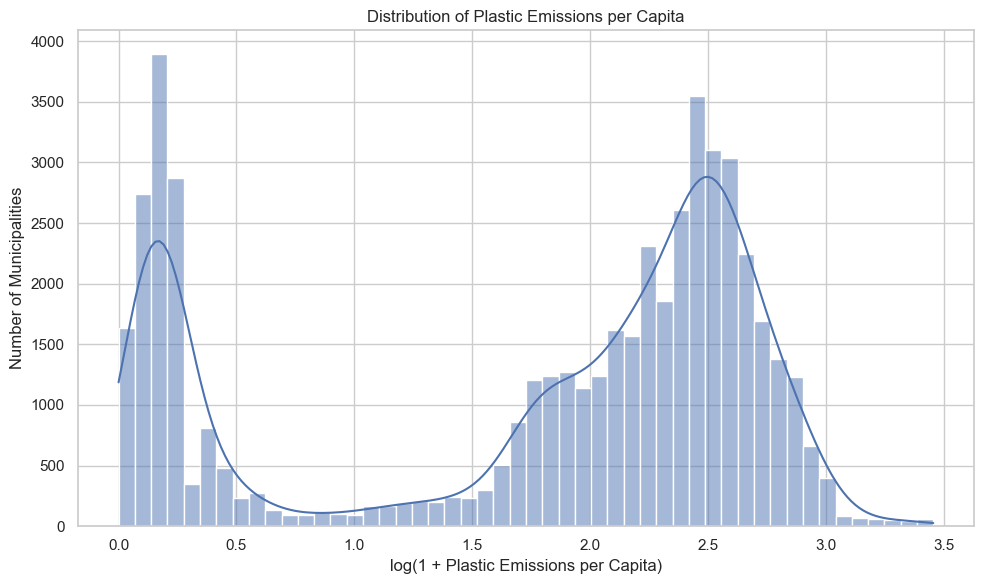

In [74]:
emission_log = np.log1p(
    df_final["Plastic_emissions_per_cap"]
)

plt.figure(figsize=(10, 6))

sns.histplot(
    emission_log,
    bins=50,
    kde=True
)

plt.title(
    "Distribution of Plastic Emissions per Capita"
)

plt.xlabel(
    "log(1 + Plastic Emissions per Capita)"
)

plt.ylabel(
    "Number of Municipalities"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "01_distribution_plastic_emissions_per_capita.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Nhận xét:**  
Sau phép biến đổi logarit, phân phối `Plastic_emissions_per_cap` không tập trung quanh một đỉnh duy nhất mà xuất hiện hai vùng tập trung tương đối rõ. Một nhóm municipality có mức phát thải bình quân đầu người thấp, trong khi một nhóm lớn khác tập trung ở mức cao hơn.
Điều này cho thấy mức phát thải bình quân đầu người giữa các municipality không đồng nhất và có thể tồn tại những nhóm có đặc điểm quản lý chất thải khác nhau. Vì vậy, các phân tích tiếp theo cần xem xét thêm yếu tố thu gom, tái chế và khu vực địa lý thay vì chỉ sử dụng giá trị trung bình toàn bộ dữ liệu.

## 2.3. Các quốc gia có tổng lượng phát thải nhựa cao nhất
Để xác định các quốc gia đóng góp lớn vào tổng lượng phát thải nhựa, dữ liệu municipality được tổng hợp theo Country bằng tổng `Plastic_emissions`.
Biểu đồ Bar Chart hiển thị 15 quốc gia có tổng lượng phát thải cao nhất.

In [75]:
country_emissions = (
    df_final
    .groupby(
        "Country",
        as_index=False
    )["Plastic_emissions"]
    .sum()
    .sort_values(
        "Plastic_emissions",
        ascending=False
    )
)

top15_country_emissions = (
    country_emissions.head(15)
)

display(top15_country_emissions)

,Country,Plastic_emissions
96,India,"9,275,776.99"
154,Nigeria,"3,532,479.16"
97,Indonesia,"3,352,228.79"
43,China,"2,808,178.92"
162,Pakistan,"2,567,460.56"
17,Bangladesh,"1,748,214.66"
179,Russia,"1,702,453.50"
29,Brazil,"1,444,823.59"
217,Thailand,"995,718.49"
56,Democratic Republic of the Congo,"963,327.79"


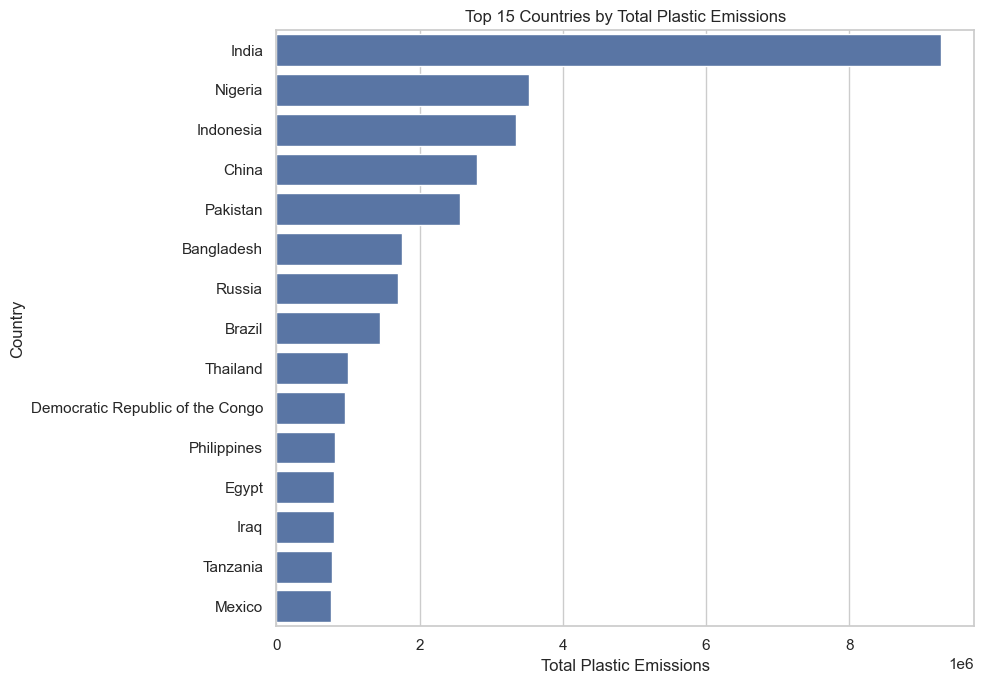

In [76]:
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top15_country_emissions,
    x="Plastic_emissions",
    y="Country"
)

plt.title(
    "Top 15 Countries by Total Plastic Emissions"
)

plt.xlabel(
    "Total Plastic Emissions"
)

plt.ylabel(
    "Country"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "02_top15_countries_plastic_emissions.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Nhận xét:**  
India có tổng lượng phát thải nhựa cao nhất trong dữ liệu, đạt khoảng 9,28 triệu đơn vị theo kết quả mô hình, cao hơn đáng kể so với Nigeria (3,53 triệu) và Indonesia (3,35 triệu). China và Pakistan lần lượt đứng ở các vị trí tiếp theo.
Khoảng cách lớn giữa India và các quốc gia còn lại cho thấy tổng lượng phát thải nhựa tập trung mạnh ở một số quốc gia. Tuy nhiên, đây là chỉ tiêu tuyệt đối nên có thể chịu ảnh hưởng của quy mô dân số và lượng chất thải phát sinh. Vì vậy cần kết hợp thêm các chỉ tiêu bình quân đầu người và hiệu quả quản lý chất thải trước khi đánh giá mức độ ô nhiễm tương đối giữa các quốc gia.

## 2.4. Mối quan hệ giữa tỷ lệ tái chế và tỷ lệ phát thải nhựa
Scatter Plot được sử dụng để khảo sát mối quan hệ giữa `Recycling_pct_gen` và calculated field `Plastic_emission_rate_pct`.
Mục tiêu là kiểm tra liệu các municipality có tỷ lệ tái chế cao hơn có xu hướng xuất hiện mức thất thoát nhựa ra môi trường thấp hơn hay không.
Biểu đồ được sử dụng để khám phá mối liên hệ, không được xem là bằng chứng về quan hệ nhân quả.

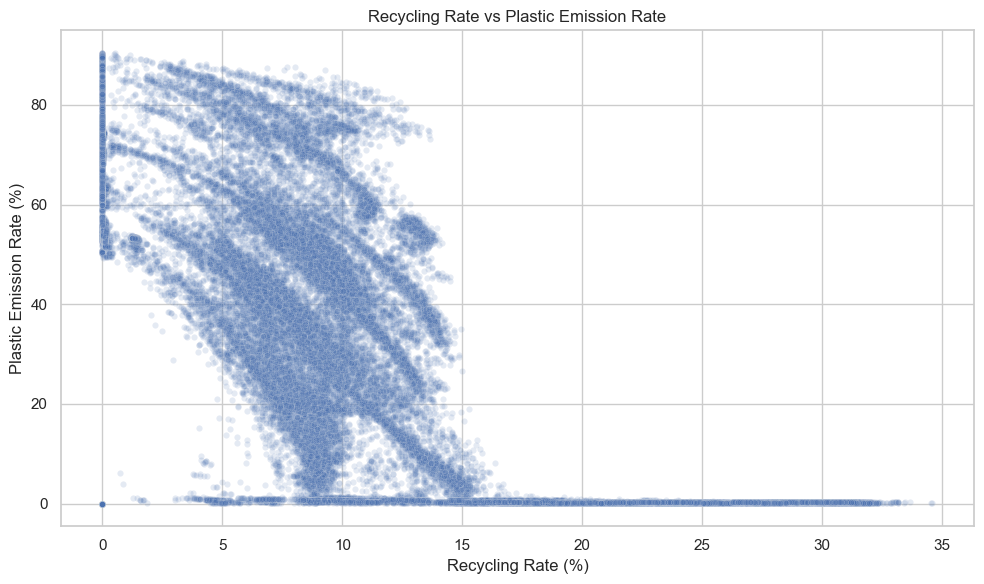

In [77]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_final,
    x="Recycling_pct_gen",
    y="Plastic_emission_rate_pct",
    alpha=0.15,
    s=20
)

plt.title(
    "Recycling Rate vs Plastic Emission Rate"
)

plt.xlabel(
    "Recycling Rate (%)"
)

plt.ylabel(
    "Plastic Emission Rate (%)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "03_recycling_vs_emission_rate.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [78]:
recycling_emission_corr = (
    df_final[
        [
            "Recycling_pct_gen",
            "Plastic_emission_rate_pct"
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

print(
    "Pearson correlation - Recycling vs Emission Rate:",
    round(recycling_emission_corr, 4)
)

Pearson correlation - Recycling vs Emission Rate: -0.75


**Nhận xét:**  
Hệ số tương quan Pearson giữa tỷ lệ tái chế và tỷ lệ phát thải nhựa đạt khoảng **-0,75**, cho thấy mối liên hệ nghịch tương đối mạnh trong tập dữ liệu.
Nhìn chung, các municipality có tỷ lệ tái chế cao hơn có xu hướng xuất hiện tỷ lệ phát thải nhựa thấp hơn. Tuy nhiên, kết quả này chỉ phản ánh mối liên hệ thống kê và không chứng minh quan hệ nhân quả.
Ngoài ra, các biến tái chế và phát thải đều là thành phần trong cùng mô hình Material Flow Analysis, vì vậy một phần mối liên hệ có thể đến từ cấu trúc của mô hình. Kết quả cần được diễn giải như một mối quan hệ trong dữ liệu mô hình hóa thay vì bằng chứng độc lập về tác động của tái chế.

## 2.5. Mối quan hệ giữa độ bao phủ thu gom và tỷ lệ phát thải nhựa
Scatter Plot tiếp theo khảo sát mối quan hệ giữa độ bao phủ dịch vụ thu gom chất thải và tỷ lệ phát thải nhựa.
Biến `Collection_coverage_pct_gen_exc_litter` thể hiện mức bao phủ thu gom, trong khi `Plastic_emission_rate_pct` phản ánh tỷ lệ rác nhựa trở thành phát thải.
Phân tích giúp đánh giá liệu các municipality có hệ thống thu gom tốt hơn có xu hướng kiểm soát phát thải nhựa hiệu quả hơn hay không.

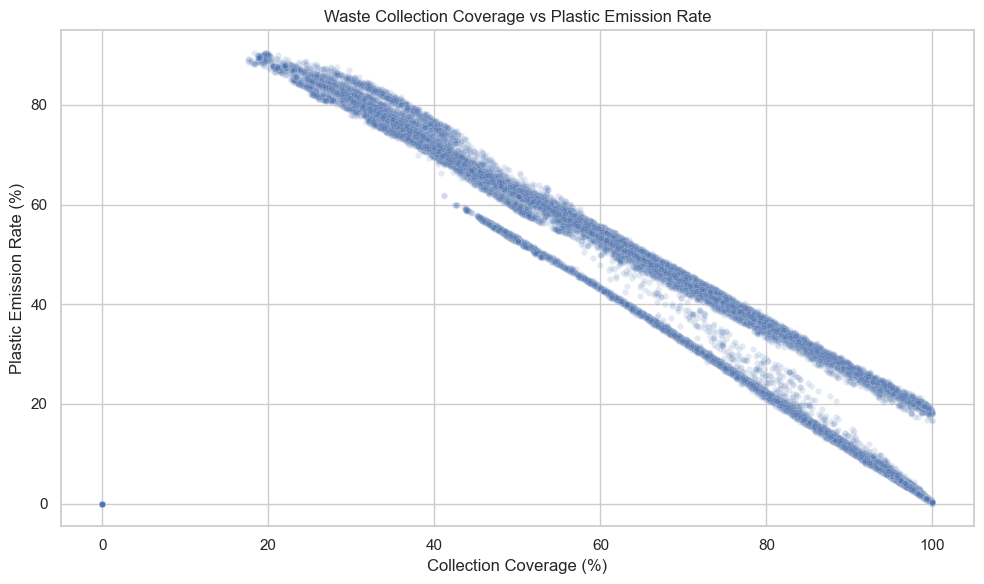

In [79]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df_final,
    x="Collection_coverage_pct_gen_exc_litter",
    y="Plastic_emission_rate_pct",
    alpha=0.15,
    s=20
)

plt.title(
    "Waste Collection Coverage vs Plastic Emission Rate"
)

plt.xlabel(
    "Collection Coverage (%)"
)

plt.ylabel(
    "Plastic Emission Rate (%)"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "04_collection_vs_emission_rate.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [80]:
collection_emission_corr = (
    df_final[
        [
            "Collection_coverage_pct_gen_exc_litter",
            "Plastic_emission_rate_pct"
        ]
    ]
    .corr(method="pearson")
    .iloc[0, 1]
)

print(
    "Pearson correlation - Collection vs Emission Rate:",
    round(collection_emission_corr, 4)
)

Pearson correlation - Collection vs Emission Rate: -0.955


**Nhận xét:**  
Hệ số tương quan Pearson giữa độ bao phủ thu gom và tỷ lệ phát thải nhựa đạt khoảng **-0,955**, thể hiện mối liên hệ nghịch rất mạnh.
Các municipality có độ bao phủ thu gom cao có xu hướng có tỷ lệ phát thải nhựa thấp hơn rõ rệt. Điều này cho thấy khả năng thu gom chất thải là một biến quan trọng khi phân tích sự khác biệt về phát thải nhựa giữa các municipality.
Tuy nhiên, vì cả độ bao phủ thu gom và phát thải đều tham gia trong cùng hệ thống Material Flow Analysis, hệ số tương quan cao có thể một phần phản ánh cấu trúc của mô hình. Do đó, kết quả không nên được diễn giải trực tiếp như bằng chứng nhân quả.

## 2.6. Cơ cấu nguồn phát thải nhựa chủ đạo theo khu vực
Để so sánh cơ chế phát thải giữa các khu vực, nhóm sử dụng calculated field `Dominant_emission_source`.
Do số lượng municipality giữa các Region khác nhau, dữ liệu được chuẩn hóa theo tỷ lệ phần trăm trong từng Region thay vì sử dụng số lượng tuyệt đối.
Biểu đồ Stacked Bar thể hiện tỷ trọng municipality thuộc ba nhóm: Plastic debris, Open burning và No emission.

In [81]:
region_source_pct = pd.crosstab(
    df_final["Region_name"],
    df_final["Dominant_emission_source"],
    normalize="index"
) * 100

display(region_source_pct.round(2))

Dominant_emission_source,No emission,Open burning,Plastic debris
Region_name,,,
Africa,0.23,19.89,79.88
Americas,0.09,68.07,31.85
Asia,0.21,51.34,48.45
Europe,0.46,39.35,60.18
Oceania,1.52,8.56,89.92


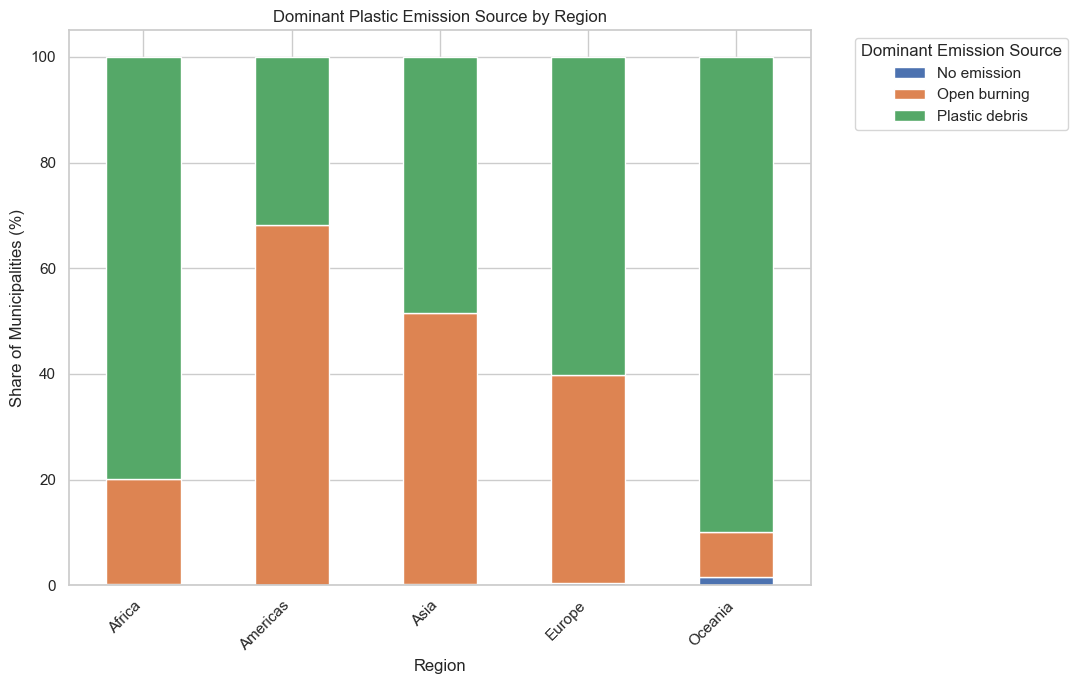

In [82]:
region_source_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(11, 7)
)

plt.title(
    "Dominant Plastic Emission Source by Region"
)

plt.xlabel(
    "Region"
)

plt.ylabel(
    "Share of Municipalities (%)"
)

plt.legend(
    title="Dominant Emission Source",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        figures_dir,
        "05_emission_source_by_region.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Nhận xét:**  
Cơ cấu nguồn phát thải chủ đạo khác biệt rõ rệt giữa các khu vực.
- Oceania có tỷ lệ municipality mà Plastic debris là nguồn phát thải chủ đạo cao nhất, khoảng **89,92%**.
- Africa cũng chủ yếu thuộc nhóm Plastic debris, khoảng **79,88%**.
- Europe có Plastic debris chiếm ưu thế với khoảng **60,18%**.
- Americas có xu hướng ngược lại, khi Open burning là nguồn chủ đạo tại khoảng **68,07%** municipality.
- Asia có cơ cấu cân bằng hơn, với Open burning khoảng **51,34%** và Plastic debris khoảng **48,45%**.
Biểu đồ thể hiện tỷ lệ municipality theo **nguồn phát thải chủ đạo**, không phải tỷ trọng khối lượng phát thải của từng nguồn. Vì vậy không nên diễn giải rằng 89,92% tổng phát thải của Oceania là Plastic debris.

## 2.7. Tổng hợp kết quả EDA
Quá trình EDA tập trung vào phân phối phát thải, sự khác biệt giữa các quốc gia và mối liên hệ giữa quản lý chất thải với phát thải nhựa.
Năm biểu đồ được sử dụng gồm:
- Histogram phân phối phát thải nhựa bình quân đầu người.
- Bar Chart các quốc gia có tổng phát thải cao nhất.
- Scatter Plot giữa tỷ lệ tái chế và tỷ lệ phát thải.
- Scatter Plot giữa độ bao phủ thu gom và tỷ lệ phát thải.
- Stacked Bar Chart về nguồn phát thải chủ đạo theo khu vực.
Các kết quả EDA sẽ được sử dụng để lựa chọn các KPI, biểu đồ, bộ lọc và luồng tương tác trong Dashboard.

# 3. CHUẨN BỊ DỮ LIỆU CHO DASHBOARD
Sau khi hoàn thành quá trình tiền xử lý, biến đổi và EDA, nhóm xây dựng tập dữ liệu cuối cùng phục vụ trực quan hóa trên Tableau.
Thay vì xuất toàn bộ các biến kỹ thuật của mô hình, nhóm chỉ lựa chọn các thuộc tính cần thiết cho:
- Phân tích theo quốc gia, khu vực và municipality.
- Phân tích dân số và điều kiện kinh tế - xã hội.
- Phân tích phát sinh chất thải.
- Thu gom và tái chế.
- Phát thải nhựa.
- Các calculated fields đã xây dựng.
Việc giảm số lượng thuộc tính giúp Dashboard dễ quản lý hơn và hạn chế sử dụng nhầm các biến trung gian.

In [83]:
dashboard_cols = [
    # Khóa và địa lý
    "UniqueID",
    "ISO3",
    "Country",
    "Municipality",
    "Region_name",
    "Subregion_name",

    # Phân loại
    "Income_category",
    "Developing_country",
    "Small_island_developing_state",
    "Capital_city",
    "World_city",
    "Mega_city",
    "Major_city",

    # Dân số và đô thị hóa
    "Population_2020",
    "Population_density",
    "Urban_centre_share",
    "Urban_cluster_share",
    "Rural_share",

    # Kinh tế - xã hội
    "GDP_PerCapita_PPP",
    "HDI",
    "GNI_per_capita",
    "Corruption_perception_index",
    "Social_progress_index",

    # Phát sinh chất thải
    "Waste_gen",
    "Waste_gen_per_cap",
    "Plastic_waste_gen",
    "Plastic_waste_gen_per_cap",

    # Thu gom
    "Collection_coverage_pct_gen_exc_litter",
    "Collection_delivered_pct_gen",
    "Litter_pct_gen",
    "Uncollected_waste_pct_gen",

    # Tái chế
    "Recycling_pct_gen",

    # Phát thải nhựa
    "Plastic_debris_emissions",
    "Plastic_openly_burned",
    "Plastic_emissions",
    "Plastic_debris_emissions_per_cap",
    "Plastic_openly_burned_emissions_per_cap",
    "Plastic_emissions_per_cap",

    # Dân số chưa được thu gom
    "People_without_collection",
    "People_without_collection_pct",

    # Calculated Fields
    "Plastic_waste_share_pct",
    "Plastic_emission_rate_pct",
    "Recycling_gap_pct",
    "Collection_coverage_gap_pct",
    "Dominant_emission_source",
    "Emission_level"
]

dashboard_df = df_final[
    dashboard_cols
].copy()

In [84]:
# Bổ sung tên municipality từ cấp hành chính gốc
# nếu SD05 không cung cấp tên Municipality
dashboard_df["Municipality"] = (
    dashboard_df["Municipality"]
    .fillna(df_final["Name_1"])
)

# Một số bản ghi nguồn không cung cấp tên Region/Subregion
# nên giữ dưới nhãn Unknown thay vì tự suy đoán
dashboard_df["Region_name"] = (
    dashboard_df["Region_name"]
    .fillna("Unknown")
)

dashboard_df["Subregion_name"] = (
    dashboard_df["Subregion_name"]
    .fillna("Unknown")
)

## 3.2. Kiểm tra tập dữ liệu cuối
Trước khi xuất dữ liệu sang Tableau, tập dữ liệu cuối được kiểm tra lại số dòng, số thuộc tính, giá trị thiếu, khóa trùng lặp và giá trị vô hạn.
Mục tiêu là đảm bảo dữ liệu đưa vào Dashboard có cấu trúc ổn định và không phát sinh lỗi từ các bước tiền xử lý trước đó.

In [85]:
print(
    "Số dòng:",
    dashboard_df.shape[0]
)

print(
    "Số cột:",
    dashboard_df.shape[1]
)

print(
    "UniqueID:",
    dashboard_df["UniqueID"].nunique()
)

print(
    "Duplicate UniqueID:",
    dashboard_df["UniqueID"].duplicated().sum()
)

print(
    "Tổng missing:",
    dashboard_df.isna().sum().sum()
)

Số dòng: 50702
Số cột: 46
UniqueID: 50702
Duplicate UniqueID: 0
Tổng missing: 0


In [86]:
dashboard_numeric_cols = (
    dashboard_df
    .select_dtypes(include=np.number)
    .columns
)

infinite_count = np.isinf(
    dashboard_df[dashboard_numeric_cols]
).sum().sum()

print(
    "Tổng giá trị vô hạn:",
    infinite_count
)

Tổng giá trị vô hạn: 0


In [87]:
dashboard_summary = pd.DataFrame({
    "Rows": [len(dashboard_df)],
    "Columns": [dashboard_df.shape[1]],
    "Unique_IDs": [
        dashboard_df["UniqueID"].nunique()
    ],
    "Duplicate_IDs": [
        dashboard_df["UniqueID"]
        .duplicated()
        .sum()
    ],
    "Missing_Values": [
        dashboard_df.isna()
        .sum()
        .sum()
    ],
    "Infinite_Values": [
        infinite_count
    ]
})

display(dashboard_summary)

,Rows,Columns,Unique_IDs,Duplicate_IDs,Missing_Values,Infinite_Values
0,50702,46,50702,0,0,0


## 3.3. Xuất dữ liệu phục vụ Tableau
Tập dữ liệu sau cùng được xuất dưới định dạng CSV với mã hóa UTF-8 nhằm đảm bảo khả năng tương thích với Tableau và giữ nguyên các ký tự quốc tế trong tên quốc gia, khu vực và municipality.

In [88]:
tableau_output_path = (
    PROCESSED_DIR / "plastic_pollution_dashboard.csv"
)

dashboard_df.to_csv(
    tableau_output_path,
    index=False,
    encoding="utf-8-sig"
)

print("Đã xuất dataset Tableau:")
print(tableau_output_path)

Đã xuất dataset Tableau:
D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\processed\plastic_pollution_dashboard.csv


In [89]:
dashboard_test = pd.read_csv(
    tableau_output_path
)

print(
    "Kích thước file sau khi đọc lại:",
    dashboard_test.shape
)

print(
    "Duplicate UniqueID:",
    dashboard_test["UniqueID"]
    .duplicated()
    .sum()
)

print(
    "Tổng missing:",
    dashboard_test
    .isna()
    .sum()
    .sum()
)

display(
    dashboard_test.head()
)

Kích thước file sau khi đọc lại: (50702, 46)
Duplicate UniqueID: 0
Tổng missing: 0


,UniqueID,ISO3,Country,Municipality,Region_name,Subregion_name,Income_category,Developing_country,Small_island_developing_state,Capital_city,World_city,Mega_city,Major_city,Population_2020,Population_density,Urban_centre_share,Urban_cluster_share,Rural_share,GDP_PerCapita_PPP,HDI,GNI_per_capita,Corruption_perception_index,Social_progress_index,Waste_gen,Waste_gen_per_cap,Plastic_waste_gen,Plastic_waste_gen_per_cap,Collection_coverage_pct_gen_exc_litter,Collection_delivered_pct_gen,Litter_pct_gen,Uncollected_waste_pct_gen,Recycling_pct_gen,Plastic_debris_emissions,Plastic_openly_burned,Plastic_emissions,Plastic_debris_emissions_per_cap,Plastic_openly_burned_emissions_per_cap,Plastic_emissions_per_cap,People_without_collection,People_without_collection_pct,Plastic_waste_share_pct,Plastic_emission_rate_pct,Recycling_gap_pct,Collection_coverage_gap_pct,Dominant_emission_source,Emission_level
0,ABW,ABW,Aruba,Aruba,Americas,Latin America and the Caribbean,HIC,1,1,0,0,0,0,"106,476.81",569.09,0.52,0.43,0.05,"25,314.40",0.83,"26,180.00",76.00,85.30,"62,714.39",1.61,"9,606.59",0.25,99.41,99.30,0.05,0.59,6.41,48.40,19.25,67.65,0.45,0.18,0.64,625.42,0.59,15.32,0.70,93.59,0.59,Plastic debris,Medium
1,AFG.1.1_1,AFG,Afghanistan,Baharak,Asia,Southern Asia,LIC,1,0,0,0,0,0,"157,502.78",43.34,0.00,0.76,0.24,"1,820.30",0.48,610.00,11.00,36.58,"35,863.90",0.62,"3,356.96",0.06,59.26,56.99,1.53,40.00,7.01,"1,123.61",761.51,"1,885.11",7.13,4.83,11.97,"64,163.96",40.74,9.36,56.16,92.99,40.74,Plastic debris,Very High
2,AFG.1.2_1,AFG,Afghanistan,Darwaz,Asia,Southern Asia,LIC,1,0,0,0,0,0,"112,779.06",31.48,0.00,0.60,0.40,"1,820.30",0.49,610.00,11.00,36.58,"23,482.72",0.57,"2,100.41",0.05,56.03,53.85,1.57,43.18,6.45,780.85,456.65,"1,237.50",6.92,4.05,10.97,"49,588.80",43.97,8.94,58.92,93.55,43.97,Plastic debris,High
3,AFG.1.3_1,AFG,Afghanistan,Fayzabad,Asia,Southern Asia,LIC,1,0,0,0,0,0,"459,501.87",126.95,0.57,0.30,0.13,"1,820.30",0.48,610.00,11.00,36.58,"108,838.40",0.65,"10,748.97",0.06,61.69,59.57,1.35,37.68,7.54,"3,270.78","2,477.83","5,748.61",7.12,5.39,12.51,"176,035.97",38.31,9.88,53.48,92.46,38.31,Plastic debris,Very High
4,AFG.1.4_1,AFG,Afghanistan,Ishkashim,Asia,Southern Asia,LIC,1,0,0,0,0,0,"26,287.51",13.15,0.00,0.33,0.67,"1,820.30",0.48,610.00,11.00,36.58,"4,416.35",0.46,332.74,0.03,47.38,45.49,1.74,51.61,5.12,156.74,66.39,223.13,5.96,2.53,8.49,"13,831.83",52.62,7.53,67.06,94.88,52.62,Plastic debris,High


## 3.4. Tổng kết dữ liệu cho Dashboard
Tập dữ liệu cuối giữ nguyên 50.702 municipality và sử dụng `UniqueID` làm khóa duy nhất.
Dataset bao gồm các nhóm thuộc tính chính về:
- Địa lý và phân loại quốc gia.
- Dân số và đô thị hóa.
- Điều kiện kinh tế - xã hội.
- Phát sinh chất thải.
- Thu gom và tái chế.
- Phát thải nhựa.
- Các calculated fields được xây dựng trong quá trình phân tích.
Tập dữ liệu được xuất dưới định dạng CSV và sẽ được sử dụng làm nguồn dữ liệu chính cho Tableau Dashboard.

# 4. MACHINE LEARNING VÀ DỰ BÁO PHÁT THẢI NHỰA
## 4.1. Mục tiêu và lựa chọn mô hình
Sau quá trình tiền xử lý, Join/Merge, tạo calculated fields, EDA và chuẩn bị dữ liệu cho Dashboard, nghiên cứu tiếp tục áp dụng Machine Learning nhằm khai thác sâu hơn các yếu tố liên quan đến phát thải nhựa tại cấp municipality.
Giai đoạn Machine Learning tập trung vào ba mục tiêu:
1. Dự đoán lượng phát thải nhựa (`Plastic_emissions`) dựa trên các đặc trưng
   về phát sinh chất thải, quản lý chất thải, dân số và điều kiện kinh tế - xã hội.
2. So sánh mô hình tuyến tính với các mô hình Machine Learning phi tuyến để
   đánh giá khả năng mô hình hóa các quan hệ phức tạp trong dữ liệu.
3. Xác định các yếu tố có ảnh hưởng lớn đến phát thải và xây dựng kết quả
   dự đoán/phân loại để tích hợp trở lại Tableau Dashboard.
Các mô hình được lựa chọn gồm:
- **Linear Regression**: mô hình cơ sở (baseline), có khả năng giải thích và
  đáp ứng yêu cầu hồi quy của đề tài.
- **Random Forest Regressor**: mô hình cây có khả năng mô hình hóa quan hệ
  phi tuyến và cung cấp Feature Importance.
- **HistGradientBoosting Regressor**: mô hình boosting phù hợp với tập dữ liệu
  có số lượng quan sát lớn và có khả năng cải thiện hiệu quả dự báo.
- **Logistic Regression**: được sử dụng ở bài toán phân loại mức phát thải,
  giúp chuyển kết quả thành các nhóm dễ diễn giải và trực quan hóa.
Các mô hình hồi quy sẽ được đánh giá bằng R², MAE và RMSE trên cùng tập kiểm tra.
Mô hình có hiệu quả phù hợp nhất sẽ được sử dụng để tạo giá trị dự đoán phục vụ
Dashboard.

In [90]:
# Chia tập dữ liệu
from sklearn.model_selection import train_test_split

# Tiền xử lý
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

# Regression models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import (
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

# Classification model
from sklearn.linear_model import LogisticRegression

# Evaluation metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

RANDOM_STATE = 42

## 4.2. Chuẩn bị dữ liệu cho Machine Learning
Dữ liệu Machine Learning được lấy trực tiếp từ `dashboard_df`, là tập dữ liệu
cuối đã hoàn thành quá trình làm sạch, Join/Merge và xây dựng calculated fields.
Việc sử dụng cùng tập dữ liệu với Tableau giúp đảm bảo tính nhất quán giữa
phân tích dữ liệu, mô hình Machine Learning và Dashboard.
Một bản sao riêng được tạo cho Machine Learning để tránh làm thay đổi trực tiếp
tập dữ liệu đang được sử dụng cho Dashboard.

In [91]:
ml_df = dashboard_df.copy()

print("Kích thước dữ liệu Machine Learning:", ml_df.shape)
print("Số municipality:", len(ml_df))
print("Số UniqueID:", ml_df["UniqueID"].nunique())

Kích thước dữ liệu Machine Learning: (50702, 46)
Số municipality: 50702
Số UniqueID: 50702


## 4.3. Xác định biến mục tiêu
Bài toán hồi quy sử dụng `Plastic_emissions` làm biến mục tiêu.
Biến này biểu thị lượng phát thải nhựa của từng municipality và là chỉ tiêu trung tâm trong quá trình phân tích của đề tài.
Mục tiêu của mô hình là ước lượng `Plastic_emissions` dựa trên các đặc trưng đầu vào có thể mô tả quy mô phát sinh chất thải, hệ thống quản lý chất thải, đặc điểm dân số và điều kiện kinh tế - xã hội.

In [92]:
TARGET_REG = "Plastic_emissions"

assert TARGET_REG in ml_df.columns, \
    f"Không tìm thấy biến mục tiêu: {TARGET_REG}"

print("Biến mục tiêu Regression:", TARGET_REG)

Biến mục tiêu Regression: Plastic_emissions


In [93]:
target_summary = ml_df[
    TARGET_REG
].describe(
    percentiles=[
        0.25,
        0.50,
        0.75,
        0.90,
        0.95,
        0.99
    ]
)

display(target_summary)

print(
    "Skewness của Plastic_emissions:",
    round(
        ml_df[TARGET_REG].skew(),
        3
    )
)

count    50,702.00
mean      1,027.70
std       4,006.49
min           0.00
25%          16.54
50%         150.89
75%         807.44
90%       2,409.74
95%       4,250.57
99%      12,690.81
max     316,164.23
Name: Plastic_emissions, dtype: float64

Skewness của Plastic_emissions: 26.341


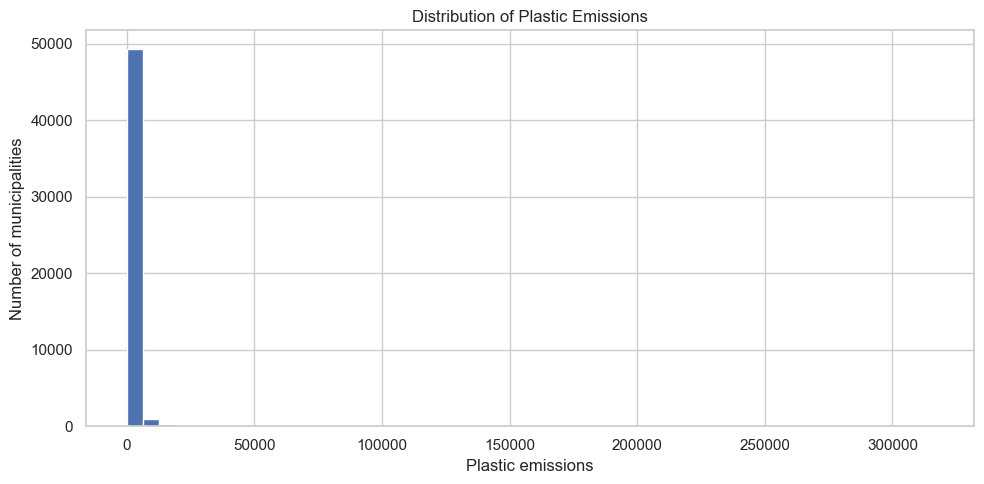

In [94]:
plt.figure(figsize=(10, 5))

plt.hist(
    ml_df[TARGET_REG],
    bins=50
)

plt.xlabel("Plastic emissions")
plt.ylabel("Number of municipalities")
plt.title(
    "Distribution of Plastic Emissions"
)

plt.tight_layout()
plt.show()

Phân phối `Plastic_emissions` được kiểm tra trước khi xây dựng mô hình.
Dữ liệu phát thải có thể xuất hiện hiện tượng lệch phải do một số municipality có lượng phát thải lớn hơn đáng kể so với phần lớn các municipality còn lại.
Đặc điểm này là một trong những lý do nghiên cứu không chỉ sử dụng Linear Regression mà còn so sánh với Random Forest và HistGradientBoosting, là các mô hình có khả năng mô hình hóa quan hệ phi tuyến tốt hơn.

## 4.4. Kiểm soát Data Leakage
Trước khi lựa chọn feature, nghiên cứu loại bỏ các biến được tính trực tiếp từ
`Plastic_emissions` hoặc chỉ có thể xác định sau khi lượng phát thải đã được biết.
Nếu những biến này được sử dụng làm predictor, mô hình có thể nhận được một phần thông tin của biến mục tiêu trước khi dự đoán, gây ra hiện tượng Data Leakage và làm kết quả đánh giá cao một cách không thực tế.
Các biến được loại khỏi tập predictor gồm các chỉ tiêu phát thải thành phần, phát thải bình quân đầu người, tỷ lệ phát thải và các calculated fields được xây dựng từ kết quả phát thải.

In [95]:
leakage_features = [
    "Plastic_emissions",
    "Plastic_emissions_per_cap",
    "Plastic_emission_rate_pct",
    "Plastic_debris_emissions",
    "Plastic_openly_burned",
    "Dominant_emission_source",
    "Emission_level"
]

print("Các biến không sử dụng làm predictor:")

for col in leakage_features:
    if col in ml_df.columns:
        print("-", col)

Các biến không sử dụng làm predictor:
- Plastic_emissions
- Plastic_emissions_per_cap
- Plastic_emission_rate_pct
- Plastic_debris_emissions
- Plastic_openly_burned
- Dominant_emission_source
- Emission_level


### 4.4.1. Lựa chọn tập đặc trưng đầu vào
Các biến đầu vào được lựa chọn nhằm đại diện cho các nhóm yếu tố về phát sinh chất thải nhựa, quản lý chất thải, dân số - đô thị hóa và điều kiện kinh tế - xã hội. Các biến có nguy cơ gây Data Leakage được loại khỏi tập predictor.

In [96]:
numeric_features = [
    # Phát sinh chất thải nhựa
    "Plastic_waste_gen",

    # Quản lý chất thải
    "Collection_coverage_pct_gen_exc_litter",
    "Recycling_pct_gen",
    "Litter_pct_gen",
    "Uncollected_waste_pct_gen",

    # Dân số và đô thị hóa
    "Population_2020",
    "Population_density",
    "Urban_centre_share",
    "Urban_cluster_share",

    # Đặc điểm đô thị
    "Capital_city",
    "World_city",
    "Mega_city",
    "Major_city",

    # Điều kiện quốc gia
    "Developing_country",
    "Small_island_developing_state",

    # Kinh tế - xã hội
    "GDP_PerCapita_PPP",
    "HDI",
    "GNI_per_capita",
    "Corruption_perception_index",
    "Social_progress_index"
]

In [97]:
categorical_features = [
    "Region_name",
    "Income_category"
]

In [98]:
# Tổng hợp danh sách biến đầu vào
selected_features = numeric_features + categorical_features

# Tóm tắt các biến được lựa chọn
feature_summary = pd.DataFrame({
    "Feature": selected_features,
    "Type": (
        ["Numerical"] * len(numeric_features)
        + ["Categorical"] * len(categorical_features)
    )
})

display(feature_summary)

,Feature,Type
0,Plastic_waste_gen,Numerical
1,Collection_coverage_pct_gen_exc_litter,Numerical
2,Recycling_pct_gen,Numerical
3,Litter_pct_gen,Numerical
4,Uncollected_waste_pct_gen,Numerical
5,Population_2020,Numerical
6,Population_density,Numerical
7,Urban_centre_share,Numerical
8,Urban_cluster_share,Numerical
9,Capital_city,Numerical


Tập predictor bao gồm 22 biến, đại diện cho các nhóm thông tin chính về phát sinh rác thải nhựa, quản lý chất thải, dân số - đô thị hóa và điều kiện kinh tế - xã hội.
Các biến định danh và các trường được tính trực tiếp từ kết quả phát thải không được sử dụng để tránh hiện tượng học thuộc dữ liệu và Data Leakage.
`Rural_share` không được đưa đồng thời cùng `Urban_centre_share` và `Urban_cluster_share` nhằm hạn chế đa cộng tuyến, do ba tỷ trọng khu vực dân cư có tổng xấp xỉ bằng 1.

### 4.4.2. Tạo tập đặc trưng X và biến mục tiêu y
Tập `X` bao gồm 22 đặc trưng được lựa chọn sau khi kiểm soát Data Leakage, trong khi `y` là lượng phát thải nhựa `Plastic_emissions`.
Các biến định danh như `UniqueID`, `Country` và `Municipality` không được sử dụng trực tiếp làm predictor vì chúng chủ yếu phục vụ nhận diện và trực quan hóa dữ liệu.

In [99]:
# Kiểm tra tất cả feature có tồn tại trong dữ liệu
missing_features = [
    col for col in selected_features
    if col not in ml_df.columns
]

assert len(missing_features) == 0, (
    f"Các feature không tồn tại trong ml_df: {missing_features}"
)

# Kiểm tra không có biến gây Data Leakage trong tập predictor
leakage_in_X = list(
    set(selected_features)
    & set(leakage_features)
)

assert len(leakage_in_X) == 0, (
    f"Phát hiện Data Leakage trong X: {leakage_in_X}"
)

# Tạo tập đặc trưng X
X = ml_df[
    selected_features
].copy()

# Tạo biến mục tiêu y
y = ml_df[
    TARGET_REG
].copy()

print("Kích thước X:", X.shape)
print("Kích thước y:", y.shape)
print("Missing trong X:", X.isna().sum().sum())
print("Missing trong y:", y.isna().sum())

Kích thước X: (50702, 22)
Kích thước y: (50702,)
Missing trong X: 0
Missing trong y: 0


## 4.5. Chia tập huấn luyện và kiểm tra
Dữ liệu được chia thành 80% Training Set và 20% Testing Set.
Training Set được sử dụng để huấn luyện mô hình, trong khi Testing Set chỉ được sử dụng để đánh giá khả năng dự đoán trên dữ liệu chưa được sử dụng trong quá trình huấn luyện.
`random_state=42` được cố định nhằm đảm bảo khả năng tái lập kết quả và giúp các mô hình được so sánh trên cùng một tập kiểm tra.

In [100]:
X_train, X_test, y_train, y_test = (
    train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=RANDOM_STATE
    )
)

print(
    "Training Set:",
    X_train.shape
)

print(
    "Testing Set:",
    X_test.shape
)

Training Set: (40561, 22)
Testing Set: (10141, 22)


## 4.6. Xây dựng Pipeline tiền xử lý
Các biến số và biến phân loại được xử lý bằng `ColumnTransformer`.
Đối với Linear Regression, các biến số được chuẩn hóa bằng StandardScaler do chúng có đơn vị và thang đo rất khác nhau.
Các biến phân loại `Region_name` và `Income_category` được chuyển thành biến số bằng One-Hot Encoding.
Toàn bộ quá trình tiền xử lý được đưa vào Pipeline nhằm đảm bảo cùng một quy trình được áp dụng nhất quán cho Training Set và Testing Set.

In [101]:
numeric_transformer_linear = Pipeline(
    steps=[
        (
            "scaler",
            StandardScaler()
        )
    ]
)

categorical_transformer = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first",
                sparse_output=False
            )
        )
    ]
)

preprocessor_linear = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_linear,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [102]:
numeric_transformer_tree = "passthrough"

preprocessor_tree = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_transformer_tree,
            numeric_features
        ),
        (
            "cat",
            categorical_transformer,
            categorical_features
        )
    ]
)

In [103]:
ml_ready_summary = pd.DataFrame({
    "Item": [
        "Total observations",
        "Training observations",
        "Testing observations",
        "Numerical features",
        "Categorical features",
        "Total features",
        "Missing in X",
        "Missing in y"
    ],
    "Value": [
        len(ml_df),
        len(X_train),
        len(X_test),
        len(numeric_features),
        len(categorical_features),
        len(selected_features),
        X.isna().sum().sum(),
        y.isna().sum()
    ]
})

display(ml_ready_summary)

,Item,Value
0,Total observations,50702
1,Training observations,40561
2,Testing observations,10141
3,Numerical features,20
4,Categorical features,2
5,Total features,22
6,Missing in X,0
7,Missing in y,0


Sau quá trình lựa chọn feature và kiểm soát Data Leakage, dữ liệu đã sẵn sàng cho quá trình huấn luyện.
Ba mô hình hồi quy gồm Linear Regression, Random Forest Regressor và HistGradientBoosting Regressor sẽ được huấn luyện trên cùng Training Set và đánh giá trên cùng Testing Set bằng R², MAE và RMSE.
Việc sử dụng cùng dữ liệu đánh giá giúp đảm bảo quá trình so sánh giữa các mô hình được thực hiện nhất quán.

## 4.7. Mô hình Linear Regression
Linear Regression được sử dụng làm mô hình cơ sở (baseline) để đánh giá khả năng dự đoán lượng phát thải nhựa từ các đặc trưng đầu vào.
Qua khảo sát ban đầu, biến mục tiêu `Plastic_emissions` có phân phối lệch phải rất mạnh với skewness khoảng 26.34. Vì vậy, mô hình được huấn luyện trên biến mục tiêu sau phép biến đổi `log1p`.
Phép biến đổi này giúp giảm ảnh hưởng của một số municipality có mức phát thải rất lớn và làm phân phối mục tiêu ổn định hơn. Sau khi dự đoán, kết quả được chuyển ngược về đơn vị phát thải ban đầu bằng `expm1`.
Hiệu quả mô hình được đánh giá trên Testing Set bằng ba chỉ số:
- **MAE**: sai số tuyệt đối trung bình.
- **RMSE**: nhấn mạnh các trường hợp dự đoán sai lớn.
- **R²**: mức độ biến thiên của phát thải được mô hình giải thích.

### 4.7.1. Biến đổi target

In [104]:
# Biến đổi logarithm cho biến mục tiêu
# nhằm giảm ảnh hưởng của phân phối lệch phải

y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

print(
    "Skewness y_train trước log:",
    round(y_train.skew(), 3)
)

print(
    "Skewness y_train sau log1p:",
    round(pd.Series(y_train_log).skew(), 3)
)

Skewness y_train trước log: 27.335
Skewness y_train sau log1p: -0.152


### 4.7.2. Xây dựng Linear Regression Pipeline

In [105]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_linear
        ),
        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 4.7.3. Huấn luyện mô hình

In [106]:
# Huấn luyện Linear Regression
# trên target đã biến đổi log1p

linear_model.fit(
    X_train,
    y_train_log
)

print("Huấn luyện Linear Regression hoàn tất.")

Huấn luyện Linear Regression hoàn tất.


### 4.7.4. Dự đoán trên Testing Set

In [107]:
# Dự đoán trên thang log
linear_pred_log = linear_model.predict(
    X_test
)

# Chuyển dự đoán trở lại đơn vị phát thải ban đầu
linear_pred = np.expm1(
    linear_pred_log
)

# Plastic emissions không thể âm
linear_pred = np.clip(
    linear_pred,
    0,
    None
)

print(
    "Số dự đoán:",
    len(linear_pred)
)

print(
    "Giá trị dự đoán nhỏ nhất:",
    round(linear_pred.min(), 2)
)

print(
    "Giá trị dự đoán lớn nhất:",
    round(linear_pred.max(), 2)
)

Số dự đoán: 10141
Giá trị dự đoán nhỏ nhất: 0.0
Giá trị dự đoán lớn nhất: 1124651.25


### 4.7.5. Kiểm tra prediction

In [108]:
assert len(linear_pred) == len(y_test), (
    "Số lượng prediction không khớp y_test."
)

assert np.isfinite(linear_pred).all(), (
    "Prediction chứa NaN hoặc Infinity."
)

assert (linear_pred >= 0).all(), (
    "Prediction còn giá trị âm."
)

print("Prediction hợp lệ.")

Prediction hợp lệ.


### 4.7.6. Đánh giá Linear Regression

In [109]:
linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

# R² trên thang log chỉ dùng bổ sung để đánh giá
linear_r2_log = r2_score(
    y_test_log,
    linear_pred_log
)

linear_metrics = pd.DataFrame({
    "Model": [
        "Linear Regression"
    ],
    "MAE": [
        linear_mae
    ],
    "RMSE": [
        linear_rmse
    ],
    "R2": [
        linear_r2
    ],
    "R2_log_scale": [
        linear_r2_log
    ]
})

display(
    linear_metrics.round(4)
)

,Model,MAE,RMSE,R2,R2_log_scale
0,Linear Regression,847.53,"11,877.50",-11.85,0.81


### 4.7.7. Tạo bảng Actual vs Predicted

In [110]:
linear_prediction_df = ml_df.loc[
    X_test.index,
    [
        "UniqueID",
        "Country",
        "Municipality"
    ]
].copy()

linear_prediction_df[
    "Actual_Plastic_Emissions"
] = y_test.values

linear_prediction_df[
    "Predicted_Plastic_Emissions"
] = linear_pred

linear_prediction_df[
    "Absolute_Error"
] = np.abs(
    linear_prediction_df[
        "Actual_Plastic_Emissions"
    ]
    -
    linear_prediction_df[
        "Predicted_Plastic_Emissions"
    ]
)

display(
    linear_prediction_df.head(10)
)

,UniqueID,Country,Municipality,Actual_Plastic_Emissions,Predicted_Plastic_Emissions,Absolute_Error
28373,MEX.22.15_1,Mexico,San Joaquín,115.72,88.71,27.01
25026,JPN.23.19_1,Japan,Shima,6.34,5.77,0.57
30774,NGA.17.21_1,Nigeria,Orsu,"3,379.65","11,145.04","7,765.39"
14631,CZE.1.2_1,Czech Republic,Český Krumlov,22.00,6.38,15.62
24580,JPN.12.95_1,Japan,Niikappu,1.09,1.59,0.50
4579,BRA.6.37_1,Brazil,Cariré,182.16,134.29,47.88
5921,BRA.13.453_1,Brazil,Madre de deus de Minas,52.68,62.07,9.39
18664,GHA.9.13_1,Ghana,North Tongu,"1,965.98","1,660.36",305.62
21385,IND.11.6.4_1,India,Hansot Mahal,371.27,501.17,129.90
14522,CUB.7.7_1,Cuba,Frak País,77.18,841.98,764.80


### 4.7.8. Actual vs Predicted

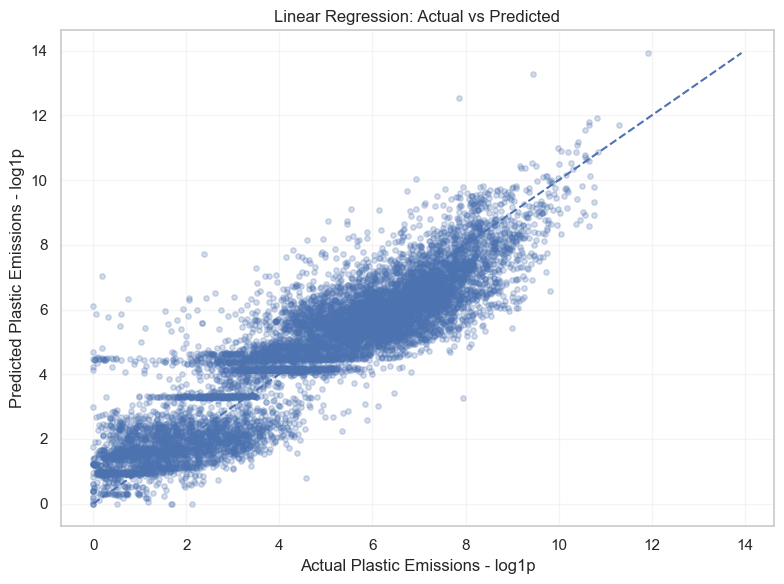

In [111]:
actual_log_plot = np.log1p(
    y_test.to_numpy()
)

pred_log_plot = np.log1p(
    linear_pred
)

plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    actual_log_plot,
    pred_log_plot,
    alpha=0.25,
    s=15
)

plot_min = min(
    actual_log_plot.min(),
    pred_log_plot.min()
)

plot_max = max(
    actual_log_plot.max(),
    pred_log_plot.max()
)

plt.plot(
    [plot_min, plot_max],
    [plot_min, plot_max],
    linestyle="--"
)

plt.xlabel(
    "Actual Plastic Emissions - log1p"
)

plt.ylabel(
    "Predicted Plastic Emissions - log1p"
)

plt.title(
    "Linear Regression: Actual vs Predicted"
)

plt.grid(
    alpha=0.2
)

plt.tight_layout()

plt.show()

### 4.7.9. Nhận xét mô hình Linear Regression
Sau phép biến đổi `log1p`, độ lệch của biến mục tiêu giảm mạnh từ 27.335 xuống -0.152, cho thấy phép biến đổi đã giúp phân phối dữ liệu trở nên cân đối hơn.
Linear Regression đạt R² khoảng 0.81 trên thang logarithm, cho thấy mô hình có khả năng mô tả tương đối tốt xu hướng chung của phát thải nhựa. Tuy nhiên, khi chuyển kết quả về đơn vị phát thải ban đầu, R² giảm xuống giá trị âm và RMSE tăng mạnh.
Kết quả này cho thấy quan hệ giữa các yếu tố quản lý chất thải, dân số, kinh tế - xã hội và lượng phát thải nhựa không hoàn toàn tuyến tính. 
Một số municipality có mức phát thải rất lớn cũng làm sai số trên thang đo gốc tăng đáng kể.
Do đó, Linear Regression được giữ lại với vai trò mô hình baseline và được so sánh với các mô hình phi tuyến ở các bước tiếp theo.

## 4.8. Mô hình Random Forest Regressor
Random Forest Regressor được lựa chọn nhằm khắc phục hạn chế của Linear Regression trong việc mô hình hóa các quan hệ phi tuyến.
Dữ liệu của nghiên cứu bao gồm nhiều nhóm yếu tố như lượng rác thải phát sinh, tỷ lệ thu gom, tỷ lệ tái chế, dân số, mật độ dân số và các đặc điểm kinh tế - xã hội. Mối quan hệ giữa các yếu tố này và lượng phát thải nhựa có thể không tuân theo một quan hệ tuyến tính đơn giản.
Random Forest phù hợp với bài toán vì:
- Có khả năng mô hình hóa quan hệ phi tuyến và tương tác giữa nhiều biến.
- Ít nhạy cảm với thang đo khác nhau giữa các biến.
- Có khả năng xử lý tập dữ liệu lớn với hơn 50.000 municipality.
- Cho phép xác định Feature Importance để phân tích các yếu tố có ảnh hưởng
  lớn đến phát thải nhựa.
Để đảm bảo khả năng so sánh với Linear Regression, Random Forest sử dụngcùng Training Set, Testing Set và tập 22 đặc trưng đã lựa chọn.
Biến mục tiêu tiếp tục được biến đổi bằng `log1p` do phân phối phát thải có độ lệch phải rất lớn.

### 4.8.1. Xây dựng Random Forest

In [112]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_tree
        ),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                max_depth=20,
                min_samples_leaf=2,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ]
)

rf_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 4.8.2. Huấn luyện

In [113]:
rf_model.fit(
    X_train,
    y_train_log
)

print(
    "Huấn luyện Random Forest Regressor hoàn tất."
)

Huấn luyện Random Forest Regressor hoàn tất.


### 4.8.3. Dự đoán

In [114]:
rf_pred_log = rf_model.predict(
    X_test
)

rf_pred = np.expm1(
    rf_pred_log
)

rf_pred = np.clip(
    rf_pred,
    0,
    None
)

print(
    "Số dự đoán:",
    len(rf_pred)
)

print(
    "Giá trị dự đoán nhỏ nhất:",
    round(rf_pred.min(), 2)
)

print(
    "Giá trị dự đoán lớn nhất:",
    round(rf_pred.max(), 2)
)

Số dự đoán: 10141
Giá trị dự đoán nhỏ nhất: 0.0
Giá trị dự đoán lớn nhất: 127190.62


### 4.8.4. Kiểm tra prediction

In [115]:
assert len(rf_pred) == len(y_test), (
    "Số lượng prediction không khớp y_test."
)

assert np.isfinite(rf_pred).all(), (
    "Prediction chứa NaN hoặc Infinity."
)

assert (rf_pred >= 0).all(), (
    "Prediction còn giá trị âm."
)

print(
    "Random Forest prediction hợp lệ."
)

Random Forest prediction hợp lệ.


### 4.8.5. Đánh giá Random Forest

In [116]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

rf_r2_log = r2_score(
    y_test_log,
    rf_pred_log
)

rf_metrics = pd.DataFrame({
    "Model": [
        "Random Forest"
    ],
    "MAE": [
        rf_mae
    ],
    "RMSE": [
        rf_rmse
    ],
    "R2": [
        rf_r2
    ],
    "R2_log_scale": [
        rf_r2_log
    ]
})

display(
    rf_metrics.round(4)
)

,Model,MAE,RMSE,R2,R2_log_scale
0,Random Forest,71.77,695.56,0.96,1.00


### 4.8.6. So sánh ngay với Linear Regression

In [117]:
comparison_lr_rf = pd.concat(
    [
        linear_metrics,
        rf_metrics
    ],
    ignore_index=True
)

display(
    comparison_lr_rf.round(4)
)

,Model,MAE,RMSE,R2,R2_log_scale
0,Linear Regression,847.53,"11,877.50",-11.85,0.81
1,Random Forest,71.77,695.56,0.96,1.00


### 4.8.7. Phân tích mức độ quan trọng của các đặc trưng
Ngoài khả năng dự đoán, Random Forest còn cho phép đánh giá mức độ đóng góp tương đối của các đặc trưng đối với kết quả dự đoán.
Phân tích Feature Importance giúp xác định những yếu tố mà mô hình sử dụng nhiều nhất khi ước lượng lượng phát thải nhựa. Điều này đặc biệt phù hợp với mục tiêu nghiên cứu vì không chỉ đánh giá khả năng dự đoán mà còn hỗ trợ nhận diện các nhóm yếu tố có liên quan mạnh đến phát thải nhựa.
Do dữ liệu bao gồm cả biến số và biến phân loại được One-Hot Encoding, tên các đặc trưng sau quá trình tiền xử lý được trích xuất trực tiếp từ pipeline trước khi ghép với giá trị Feature Importance của Random Forest.

In [118]:
# Lấy mô hình Random Forest đã huấn luyện
rf_estimator = rf_model.named_steps[
    "model"
]

# Lấy bộ tiền xử lý
rf_preprocessor = rf_model.named_steps[
    "preprocessor"
]

# Lấy tên feature sau preprocessing
rf_feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

# Lấy feature importance
rf_importance = (
    rf_estimator
    .feature_importances_
)

# Tạo DataFrame
rf_feature_importance_df = pd.DataFrame({
    "Feature": rf_feature_names,
    "Importance": rf_importance
})

# Sắp xếp giảm dần
rf_feature_importance_df = (
    rf_feature_importance_df
    .sort_values(
        "Importance",
        ascending=False
    )
    .reset_index(drop=True)
)

display(
    rf_feature_importance_df.head(15)
)

,Feature,Importance
0,num__Population_2020,0.33
1,num__GNI_per_capita,0.27
2,num__Social_progress_index,0.26
3,num__Plastic_waste_gen,0.11
4,num__Collection_coverage_pct_gen_exc_litter,0.01
5,num__Uncollected_waste_pct_gen,0.01
6,num__Litter_pct_gen,0.00
7,num__Population_density,0.00
8,num__Corruption_perception_index,0.00
9,num__Recycling_pct_gen,0.00


### 4.8.8. Vẽ Top 15 Feature Importance

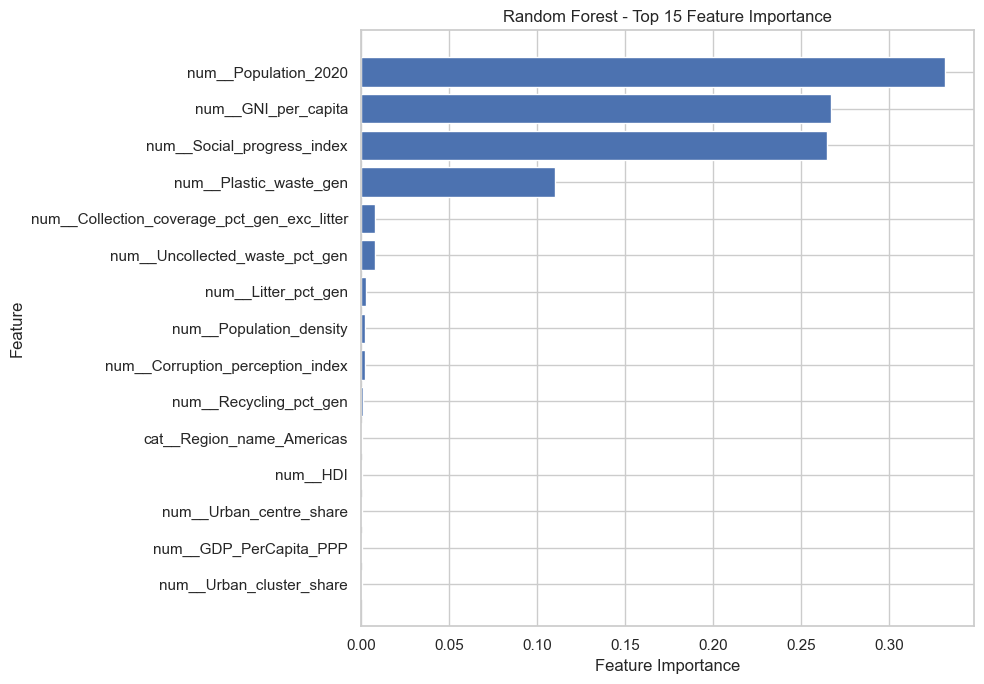

In [119]:
top_rf_features = (
    rf_feature_importance_df
    .head(15)
    .sort_values(
        "Importance",
        ascending=True
    )
)

plt.figure(
    figsize=(10, 7)
)

plt.barh(
    top_rf_features["Feature"],
    top_rf_features["Importance"]
)

plt.xlabel(
    "Feature Importance"
)

plt.ylabel(
    "Feature"
)

plt.title(
    "Random Forest - Top 15 Feature Importance"
)

plt.tight_layout()

plt.show()

### 4.8.9. Kiểm tra mức độ phụ thuộc vào feature mạnh nhất

In [120]:
top5_rf_importance = (
    rf_feature_importance_df
    .head(5)
    .copy()
)

top5_rf_importance["Importance_pct"] = (
    top5_rf_importance["Importance"]
    * 100
)

display(
    top5_rf_importance
)

print(
    "Tổng importance của Top 5:",
    round(
        top5_rf_importance[
            "Importance"
        ].sum() * 100,
        2
    ),
    "%"
)

print(
    "Importance của biến mạnh nhất:",
    round(
        rf_feature_importance_df.loc[
            0,
            "Importance"
        ] * 100,
        2
    ),
    "%"
)

,Feature,Importance,Importance_pct
0,num__Population_2020,0.33,33.15
1,num__GNI_per_capita,0.27,26.70
2,num__Social_progress_index,0.26,26.47
3,num__Plastic_waste_gen,0.11,11.03
4,num__Collection_coverage_pct_gen_exc_litter,0.01,0.82


Tổng importance của Top 5: 98.15 %
Importance của biến mạnh nhất: 33.15 %


### 4.8.10. Nhận xét mô hình Random Forest
Random Forest cải thiện rõ rệt hiệu quả dự đoán so với Linear Regression.
Trên tập kiểm tra, mô hình đạt MAE khoảng 71.77, RMSE khoảng 695.56 và R² khoảng 0.96 trên thang đo gốc. Điều này cho thấy mô hình phi tuyến phù hợp hơn đáng kể với cấu trúc dữ liệu phát thải nhựa.
Phân tích Feature Importance cho thấy các đặc trưng có đóng góp lớn nhất bao gồm Population_2020 (33.15%), GNI_per_capita (26.70%), Social_progress_index (26.47%) và Plastic_waste_gen (11.03%).
Ba biến liên quan đến quy mô dân số và điều kiện kinh tế - xã hội chiếm phần lớn mức độ quan trọng của mô hình. Kết quả cho thấy lượng phát thải nhựa có mối liên hệ mạnh với quy mô dân số và đặc điểm phát triển kinh tế - xã hội của từng municipality.
Không có một đặc trưng duy nhất chi phối gần như toàn bộ mô hình; đặc trưng quan trọng nhất chỉ chiếm khoảng 33.15%. Vì vậy chưa ghi nhận dấu hiệu mô hình phụ thuộc tuyệt đối vào một biến đầu vào đơn lẻ.
Tuy nhiên, Feature Importance của Random Forest phản ánh mức độ đóng góp cho khả năng dự đoán và không được diễn giải trực tiếp như quan hệ nhân quả.

## 4.9. Mô hình HistGradientBoosting Regressor
Sau Linear Regression và Random Forest, HistGradientBoosting Regressorđược sử dụng như một mô hình boosting phi tuyến để tiếp tục đánh giá khả năng dự đoán lượng phát thải nhựa.
Khác với Random Forest xây dựng nhiều cây độc lập và tổng hợp kết quả, Gradient Boosting xây dựng các cây tuần tự, trong đó mỗi cây mới tập trung khắc phục phần sai số còn lại của các cây trước đó.
HistGradientBoosting được lựa chọn vì:
- Có khả năng mô hình hóa các quan hệ phi tuyến phức tạp.
- Có thể mô tả tương tác giữa nhiều biến đầu vào.
- Hiệu quả trên tập dữ liệu có số lượng quan sát lớn.
- Cho phép so sánh trực tiếp với Linear Regression và Random Forest.
Để đảm bảo tính công bằng trong so sánh, mô hình sử dụng cùng Training Set, Testing Set và tập đặc trưng đã sử dụng ở các mô hình trước. Biến mục tiêu tiếp tục được biến đổi bằng log1p.

### 4.9.2. Xây dựng mô hình

In [121]:
preprocessor_hgb = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)

hgb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_hgb
        ),
        (
            "model",
            HistGradientBoostingRegressor(
                learning_rate=0.08,
                max_iter=300,
                max_leaf_nodes=31,
                min_samples_leaf=20,
                l2_regularization=0.1,
                random_state=RANDOM_STATE
            )
        )
    ]
)

hgb_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 4.9.3. Huấn luyện

In [122]:
hgb_model.fit(
    X_train,
    y_train_log
)

print(
    "Huấn luyện HistGradientBoosting Regressor hoàn tất."
)

Huấn luyện HistGradientBoosting Regressor hoàn tất.


### 4.9.4. Dự đoán

In [123]:
hgb_pred_log = hgb_model.predict(
    X_test
)

hgb_pred = np.expm1(
    hgb_pred_log
)

hgb_pred = np.clip(
    hgb_pred,
    0,
    None
)

print(
    "Số dự đoán:",
    len(hgb_pred)
)

print(
    "Giá trị dự đoán nhỏ nhất:",
    round(hgb_pred.min(), 2)
)

print(
    "Giá trị dự đoán lớn nhất:",
    round(hgb_pred.max(), 2)
)

Số dự đoán: 10141
Giá trị dự đoán nhỏ nhất: 0.0
Giá trị dự đoán lớn nhất: 113417.64


### 4.9.5. Kiểm tra prediction

In [124]:
assert len(hgb_pred) == len(y_test), (
    "Số lượng prediction không khớp y_test."
)

assert np.isfinite(hgb_pred).all(), (
    "Prediction chứa NaN hoặc Infinity."
)

assert (hgb_pred >= 0).all(), (
    "Prediction còn giá trị âm."
)

print(
    "HistGradientBoosting prediction hợp lệ."
)

HistGradientBoosting prediction hợp lệ.


### 4.9.6. Đánh giá mô hình

In [125]:
hgb_mae = mean_absolute_error(
    y_test,
    hgb_pred
)

hgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        hgb_pred
    )
)

hgb_r2 = r2_score(
    y_test,
    hgb_pred
)

hgb_r2_log = r2_score(
    y_test_log,
    hgb_pred_log
)

hgb_metrics = pd.DataFrame({
    "Model": [
        "HistGradientBoosting"
    ],
    "MAE": [
        hgb_mae
    ],
    "RMSE": [
        hgb_rmse
    ],
    "R2": [
        hgb_r2
    ],
    "R2_log_scale": [
        hgb_r2_log
    ]
})

display(
    hgb_metrics.round(4)
)

,Model,MAE,RMSE,R2,R2_log_scale
0,HistGradientBoosting,83.11,793.55,0.94,1.00


### 4.9.7. So sánh cả 3 mô hình

In [126]:
regression_comparison = pd.concat(
    [
        linear_metrics,
        rf_metrics,
        hgb_metrics
    ],
    ignore_index=True
)

regression_comparison = (
    regression_comparison
    .sort_values(
        "RMSE",
        ascending=True
    )
    .reset_index(drop=True)
)

display(
    regression_comparison.round(4)
)

,Model,MAE,RMSE,R2,R2_log_scale
0,Random Forest,71.77,695.56,0.96,1.00
1,HistGradientBoosting,83.11,793.55,0.94,1.00
2,Linear Regression,847.53,"11,877.50",-11.85,0.81


### 4.10. Kiểm tra và lựa chọn mô hình hồi quy
### 4.10.1. Kiểm tra R² log với độ chính xác cao hơn

In [127]:
print(
    "Random Forest R2 log:",
    f"{rf_r2_log:.8f}"
)

print(
    "HistGradientBoosting R2 log:",
    f"{hgb_r2_log:.8f}"
)

Random Forest R2 log: 0.99711142
HistGradientBoosting R2 log: 0.99825673


### 4.10.2. So sánh Train và Test

In [128]:
# ==============================
# RANDOM FOREST - TRAIN
# ==============================

rf_train_pred_log = rf_model.predict(
    X_train
)

rf_train_pred = np.expm1(
    rf_train_pred_log
)

rf_train_pred = np.clip(
    rf_train_pred,
    0,
    None
)

rf_train_r2 = r2_score(
    y_train,
    rf_train_pred
)


# ==============================
# HISTGRADIENTBOOSTING - TRAIN
# ==============================

hgb_train_pred_log = hgb_model.predict(
    X_train
)

hgb_train_pred = np.expm1(
    hgb_train_pred_log
)

hgb_train_pred = np.clip(
    hgb_train_pred,
    0,
    None
)

hgb_train_r2 = r2_score(
    y_train,
    hgb_train_pred
)


# ==============================
# TẠO BẢNG SO SÁNH
# ==============================

overfit_check = pd.DataFrame({
    "Model": [
        "Random Forest",
        "HistGradientBoosting"
    ],
    
    "Train_R2": [
        rf_train_r2,
        hgb_train_r2
    ],
    
    "Test_R2": [
        rf_r2,
        hgb_r2
    ]
})


overfit_check["R2_Gap"] = (
    overfit_check["Train_R2"]
    - overfit_check["Test_R2"]
)

display(
    overfit_check.round(4)
)

,Model,Train_R2,Test_R2,R2_Gap
0,Random Forest,0.94,0.96,-0.02
1,HistGradientBoosting,0.92,0.94,-0.02


### 4.10.3. So sánh chính thức 3 mô hình

In [129]:
regression_comparison_final = (
    regression_comparison.copy()
)

regression_comparison_final["Rank_RMSE"] = (
    regression_comparison_final["RMSE"]
    .rank(
        method="min",
        ascending=True
    )
    .astype(int)
)

regression_comparison_final["Rank_R2"] = (
    regression_comparison_final["R2"]
    .rank(
        method="min",
        ascending=False
    )
    .astype(int)
)

display(
    regression_comparison_final.round(4)
)

,Model,MAE,RMSE,R2,R2_log_scale,Rank_RMSE,Rank_R2
0,Random Forest,71.77,695.56,0.96,1.00,1,1
1,HistGradientBoosting,83.11,793.55,0.94,1.00,2,2
2,Linear Regression,847.53,"11,877.50",-11.85,0.81,3,3


### 4.10.4. Vẽ biểu đồ so sánh mô hình

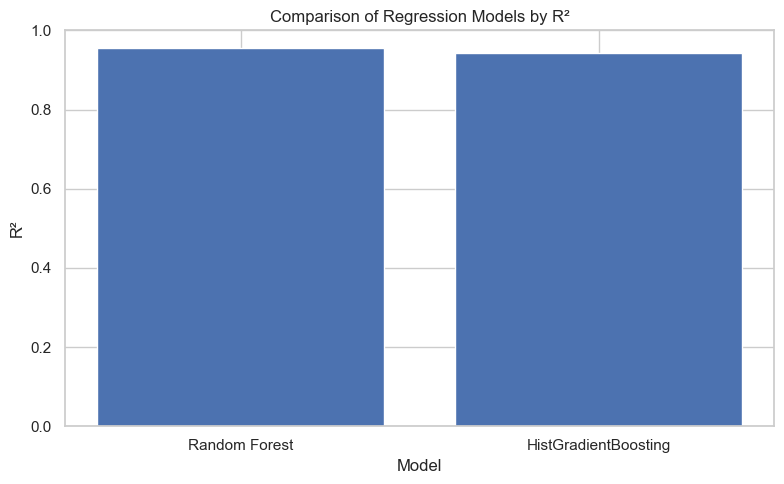

In [130]:
model_plot_df = (
    regression_comparison[
        regression_comparison["R2"] >= 0
    ]
    .copy()
)

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    model_plot_df["Model"],
    model_plot_df["R2"]
)

plt.ylabel(
    "R²"
)

plt.xlabel(
    "Model"
)

plt.title(
    "Comparison of Regression Models by R²"
)

plt.ylim(
    0,
    1
)

plt.tight_layout()

plt.show()

### 4.10.5. Lựa chọn mô hình hồi quy
Ba mô hình hồi quy gồm Linear Regression, Random Forest Regressor và HistGradientBoosting Regressor được đánh giá trên cùng tập kiểm tra.
Linear Regression cho hiệu quả thấp trên thang đo gốc, với R² âm, cho thấy mối quan hệ giữa các đặc trưng và lượng phát thải nhựa không thể được mô tả tốt bằng một quan hệ tuyến tính đơn giản.
Hai mô hình phi tuyến cho kết quả tốt hơn đáng kể. HistGradientBoosting đạt R² khoảng 0.94, trong khi Random Forest đạt R² khoảng 0.96 đồng thời có MAE và RMSE thấp nhất trong ba mô hình.
Kết quả này cho thấy dữ liệu tồn tại các mối quan hệ phi tuyến và tương tác phức tạp giữa các đặc trưng. Do đó, Random Forest được lựa chọn làm mô hình hồi quy chính để dự đoán lượng phát thải nhựa. Phân tích Feature Importance cho thấy Population_2020, GNI_per_capita,
Social_progress_index và Plastic_waste_gen là những đặc trưng có đóng góp lớn nhất vào khả năng dự đoán của mô hình.
Các mức độ quan trọng này phản ánh đóng góp của đặc trưng trong mô hình, không được diễn giải trực tiếp như quan hệ nhân quả.

## 4.11. Logistic Regression – Phân loại municipality có mức phát thải cao
Bên cạnh việc dự đoán giá trị phát thải bằng các mô hình hồi quy, nghiên cứu xây dựng thêm bài toán phân loại nhằm xác định các municipality có nguy cơ phát thải nhựa cao.
Một municipality được xếp vào nhóm High Emission nếu lượng phát thải của nó nằm trong nhóm 25% giá trị cao nhất của toàn bộ dữ liệu.
Ngưỡng được xác định bằng phân vị thứ 75 (75th percentile).
Cách tiếp cận này phù hợp với phân bố phát thải lệch phải của dữ liệu và giúp xác định nhóm địa phương cần được ưu tiên trong quản lý rác thải nhựa.

In [131]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nCác feature hiện tại:")
print(list(X.columns))

print("\nTarget:")
display(y.describe())

X shape: (50702, 22)
y shape: (50702,)

Các feature hiện tại:
['Plastic_waste_gen', 'Collection_coverage_pct_gen_exc_litter', 'Recycling_pct_gen', 'Litter_pct_gen', 'Uncollected_waste_pct_gen', 'Population_2020', 'Population_density', 'Urban_centre_share', 'Urban_cluster_share', 'Capital_city', 'World_city', 'Mega_city', 'Major_city', 'Developing_country', 'Small_island_developing_state', 'GDP_PerCapita_PPP', 'HDI', 'GNI_per_capita', 'Corruption_perception_index', 'Social_progress_index', 'Region_name', 'Income_category']

Target:


count    50,702.00
mean      1,027.70
std       4,006.49
min           0.00
25%          16.54
50%         150.89
75%         807.44
max     316,164.23
Name: Plastic_emissions, dtype: float64

### 4.11.2. Xây dựng biến mục tiêu phân loại
Biến mục tiêu nhị phân `High_Emission` được xây dựng từ lượng phát thải nhựa thực tế.
Municipality có lượng phát thải lớn hơn hoặc bằng phân vị thứ 75 của toàn bộ dữ liệu được gán nhãn 1 (High Emission), các municipality còn lại được gán nhãn 0 (Normal Emission).
Việc sử dụng phân vị thứ 75 giúp tập trung vào nhóm 25% municipality có mức phát thải cao nhất, phù hợp với mục tiêu nhận diện các khu vực cần được ưu tiên trong quản lý ô nhiễm nhựa.

In [132]:
# Ngưỡng phân loại: phân vị thứ 75 của Plastic emissions
high_emission_threshold = y.quantile(0.75)

# Tạo target classification
y_class = (
    y >= high_emission_threshold
).astype(int)

print(
    "High emission threshold:",
    round(high_emission_threshold, 2)
)

class_distribution = (
    y_class
    .value_counts()
    .sort_index()
    .rename(index={
        0: "Normal Emission",
        1: "High Emission"
    })
)

class_distribution_pct = (
    y_class
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename(index={
        0: "Normal Emission",
        1: "High Emission"
    })
)

classification_target_summary = pd.DataFrame({
    "Count": class_distribution,
    "Percent": class_distribution_pct
})

display(
    classification_target_summary.round(2)
)

High emission threshold: 807.44


,Count,Percent
Plastic_emissions,,
Normal Emission,38026,75.00
High Emission,12676,25.00


### 4.11.3. Kiểm tra target classification

In [133]:
assert len(y_class) == len(X), (
    "Số dòng của X và y_class không khớp."
)

assert y_class.isna().sum() == 0, (
    "y_class còn giá trị thiếu."
)

assert set(y_class.unique()).issubset({0, 1}), (
    "Target classification không phải nhị phân."
)

print(
    "Target classification hợp lệ."
)

Target classification hợp lệ.


### 4.11.4. Kiểm tra nhanh nguy cơ Data Leakage

In [134]:
possible_leakage_keywords = [
    "emission",
    "emissions",
    "emission_level",
    "predicted"
]

possible_leakage_features = [
    col
    for col in X.columns
    if any(
        keyword.lower() in col.lower()
        for keyword in possible_leakage_keywords
    )
]

print(
    "Các feature cần kiểm tra nguy cơ leakage:"
)

print(
    possible_leakage_features
)

Các feature cần kiểm tra nguy cơ leakage:
[]


### 4.11.5. Chia Training / Testing cho bài toán Classification

In [135]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = (
    train_test_split(
        X,
        y_class,
        test_size=0.20,
        random_state=RANDOM_STATE,
        stratify=y_class
    )
)

print(
    "Training shape:",
    X_train_cls.shape
)

print(
    "Testing shape:",
    X_test_cls.shape
)

print(
    "\nTỷ lệ High Emission trong Training:",
    round(
        y_train_cls.mean() * 100,
        2
    ),
    "%"
)

print(
    "Tỷ lệ High Emission trong Testing:",
    round(
        y_test_cls.mean() * 100,
        2
    ),
    "%"
)

Training shape: (40561, 22)
Testing shape: (10141, 22)

Tỷ lệ High Emission trong Training: 25.0 %
Tỷ lệ High Emission trong Testing: 25.0 %


### 4.11.6. Xây dựng mô hình Logistic Regression
Logistic Regression được sử dụng làm mô hình phân loại nhằm ước lượng xác suất một municipality thuộc nhóm phát thải nhựa cao.
Đối với các biến số, StandardScaler được sử dụng để chuẩn hóa thang đo do Logistic Regression nhạy với sự khác biệt về quy mô giữa các đặc trưng.
Các biến phân loại được chuyển đổi bằng One-Hot Encoding.
Tham số `class_weight="balanced"` được sử dụng nhằm giảm ảnh hưởng của sự mất cân bằng giữa nhóm Normal Emission và High Emission.

In [136]:
# Tiền xử lý dành riêng cho Logistic Regression
preprocessor_logistic = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ],
    remainder="drop"
)

# Xây dựng pipeline Logistic Regression
logistic_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor_logistic
        ),
        (
            "model",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=RANDOM_STATE
            )
        )
    ]
)

logistic_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

### 4.11.7. Huấn luyện Logistic Regression

In [137]:
logistic_model.fit(
    X_train_cls,
    y_train_cls
)

print(
    "Huấn luyện Logistic Regression hoàn tất."
)

Huấn luyện Logistic Regression hoàn tất.


### 4.11.8. Dự đoán lớp và xác suất

In [138]:
# Dự đoán class
logistic_pred = logistic_model.predict(
    X_test_cls
)

# Xác suất thuộc High Emission
logistic_prob = (
    logistic_model
    .predict_proba(
        X_test_cls
    )[:, 1]
)

print(
    "Số dự đoán:",
    len(logistic_pred)
)

print(
    "Probability nhỏ nhất:",
    round(
        logistic_prob.min(),
        4
    )
)

print(
    "Probability lớn nhất:",
    round(
        logistic_prob.max(),
        4
    )
)

Số dự đoán: 10141
Probability nhỏ nhất: 0.0
Probability lớn nhất: 1.0


### 4.11.9. Kiểm tra prediction

In [139]:
assert len(logistic_pred) == len(y_test_cls), (
    "Số lượng prediction không khớp y_test_cls."
)

assert set(
    np.unique(logistic_pred)
).issubset({0, 1}), (
    "Prediction không phải class 0/1."
)

assert (
    (logistic_prob >= 0)
    & (logistic_prob <= 1)
).all(), (
    "Probability nằm ngoài miền [0, 1]."
)

print(
    "Logistic Regression prediction hợp lệ."
)

Logistic Regression prediction hợp lệ.


### 4.11.10. Đánh giá mô hình Logistic Regression
Hiệu quả của mô hình Logistic Regression được đánh giá trên tập Testing bằng các chỉ số Accuracy, Precision, Recall, F1-score và ROC-AUC.
Do nhóm High Emission chỉ chiếm khoảng 25% dữ liệu, Accuracy không được sử dụng đơn lẻ để đánh giá mô hình. Precision, Recall và F1-score được bổ sung nhằm đánh giá khả năng phát hiện đúng các municipality có mức phát thải nhựa cao.
ROC-AUC được sử dụng để đánh giá khả năng phân biệt giữa hai nhóm trên nhiều ngưỡng phân loại khác nhau.

In [140]:
# Đánh giá Logistic Regression
logistic_accuracy = accuracy_score(
    y_test_cls,
    logistic_pred
)

logistic_precision = precision_score(
    y_test_cls,
    logistic_pred,
    zero_division=0
)

logistic_recall = recall_score(
    y_test_cls,
    logistic_pred,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_cls,
    logistic_pred,
    zero_division=0
)

logistic_auc = roc_auc_score(
    y_test_cls,
    logistic_prob
)

logistic_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC"
    ],
    "Value": [
        logistic_accuracy,
        logistic_precision,
        logistic_recall,
        logistic_f1,
        logistic_auc
    ]
})

display(
    logistic_metrics.round(4)
)

,Metric,Value
0,Accuracy,0.93
1,Precision,0.82
2,Recall,0.90
3,F1-score,0.86
4,ROC-AUC,0.98


### 4.11.11. Ma trận nhầm lẫn
Confusion Matrix được sử dụng để quan sát trực tiếp số lượng municipality được dự đoán đúng và sai ở hai nhóm Normal Emission và High Emission.
Đặc biệt, False Negative cần được chú ý vì đây là các municipality thực tế thuộc nhóm phát thải cao nhưng mô hình lại dự đoán là nhóm bình thường.

In [141]:
cm = confusion_matrix(
    y_test_cls,
    logistic_pred
)

cm_df = pd.DataFrame(
    cm,
    index=[
        "Actual Normal",
        "Actual High"
    ],
    columns=[
        "Predicted Normal",
        "Predicted High"
    ]
)

display(cm_df)

,Predicted Normal,Predicted High
Actual Normal,7097,509
Actual High,242,2293


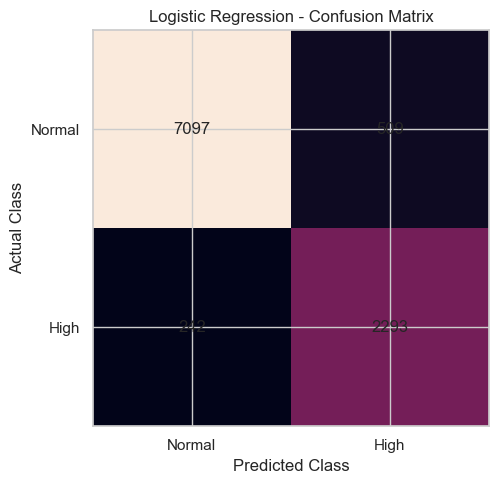

In [142]:
plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.xticks(
    [0, 1],
    ["Normal", "High"]
)

plt.yticks(
    [0, 1],
    ["Normal", "High"]
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title(
    "Logistic Regression - Confusion Matrix"
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

### 4.11.12. Classification Report

In [143]:
classification_results = pd.DataFrame(
    classification_report(
        y_test_cls,
        logistic_pred,
        target_names=[
            "Normal Emission",
            "High Emission"
        ],
        output_dict=True,
        zero_division=0
    )
).transpose()

display(
    classification_results.round(4)
)

,precision,recall,f1-score,support
Normal Emission,0.97,0.93,0.95,"7,606.00"
High Emission,0.82,0.90,0.86,"2,535.00"
accuracy,0.93,0.93,0.93,0.93
macro avg,0.89,0.92,0.90,"10,141.00"
weighted avg,0.93,0.93,0.93,"10,141.00"


### 4.11.13. ROC Curve

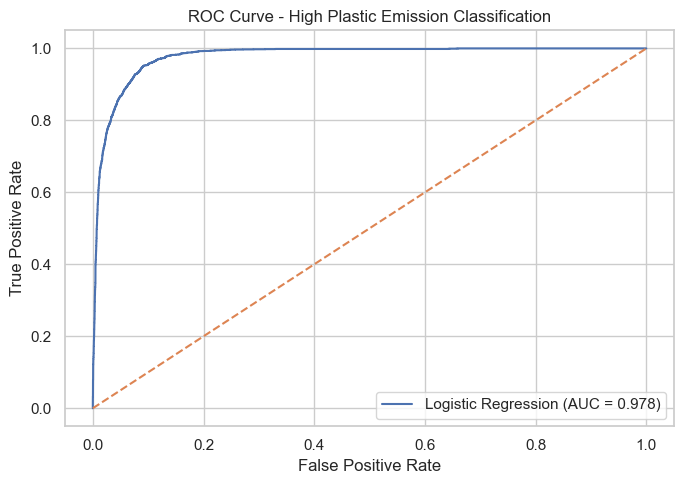

In [144]:
fpr, tpr, thresholds = roc_curve(
    y_test_cls,
    logistic_prob
)

plt.figure(figsize=(7, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(
    "ROC Curve - High Plastic Emission Classification"
)

plt.legend()
plt.tight_layout()
plt.show()

### 4.11.14. So sánh với Baseline

In [145]:
baseline_pred = np.zeros(
    len(y_test_cls),
    dtype=int
)

baseline_accuracy = accuracy_score(
    y_test_cls,
    baseline_pred
)

baseline_comparison = pd.DataFrame({
    "Model": [
        "Baseline - Predict All Normal",
        "Logistic Regression"
    ],
    "Accuracy": [
        baseline_accuracy,
        logistic_accuracy
    ],
    "Precision_High": [
        0,
        logistic_precision
    ],
    "Recall_High": [
        0,
        logistic_recall
    ],
    "F1_High": [
        0,
        logistic_f1
    ]
})

display(
    baseline_comparison.round(4)
)

,Model,Accuracy,Precision_High,Recall_High,F1_High
0,Baseline - Predict All Normal,0.75,0.00,0.00,0.00
1,Logistic Regression,0.93,0.82,0.90,0.86


### 4.11.15. Nhận xét mô hình Logistic Regression
Logistic Regression đạt Accuracy khoảng 93%, Precision khoảng 82%, Recall khoảng 90% và F1-score khoảng 86% đối với nhóm High Emission. ROC-AUC xấp xỉ 0.98 cho thấy mô hình có khả năng phân biệt rất tốt giữa nhóm phát thải cao và nhóm phát thải bình thường.
Ma trận nhầm lẫn cho thấy mô hình xác định đúng 2.293 municipality thuộc nhóm High Emission, trong khi bỏ sót 242 trường hợp. Recall cao đặc biệt có ý nghĩa trong bài toán này vì mục tiêu là nhận diện các địa phương cần được ưu tiên theo dõi và quản lý phát thải nhựa.
So với baseline luôn dự đoán Normal Emission, mặc dù baseline vẫn đạt Accuracy 75% do mất cân bằng lớp, nhưng không phát hiện được bất kỳ municipality High Emission nào. Logistic Regression cải thiện rõ rệt khả năng nhận diện nhóm nguy cơ cao.
Do đó, Logistic Regression được sử dụng như mô hình phân loại rủi ro bổ sung cho các mô hình hồi quy dự đoán lượng phát thải nhựa.

## 4.12. Tích hợp kết quả Machine Learning vào Dashboard
Sau khi xây dựng và đánh giá các mô hình Machine Learning, kết quả dự đoán được tích hợp trở lại bộ dữ liệu ở cấp municipality để phục vụ trực quan hóa trên Tableau.
Random Forest Regressor được lựa chọn làm mô hình hồi quy chính do đạt hiệu quả tốt nhất trong các mô hình đã thử nghiệm, với sai số RMSE thấp nhất và hệ số R² cao trên tập kiểm tra. Mô hình đồng thời cho kết quả ổn định giữa Training Set và Testing Set.
Kết quả dự đoán cho toàn bộ municipality sẽ được sử dụng để so sánh giá trị phát thải thực tế và phát thải dự đoán trên Dashboard.

### 4.12.1. Dự đoán lượng phát thải nhựa cho toàn bộ municipality

In [146]:
# Dự đoán log(Plastic emissions + 1) cho toàn bộ dữ liệu
rf_full_pred_log = rf_model.predict(X)

# Chuyển kết quả về đơn vị phát thải ban đầu
rf_full_pred = np.expm1(
    rf_full_pred_log
)

# Không cho phép giá trị phát thải âm
rf_full_pred = np.clip(
    rf_full_pred,
    0,
    None
)

print(
    "Số municipality được dự đoán:",
    len(rf_full_pred)
)

print(
    "Giá trị dự đoán nhỏ nhất:",
    round(rf_full_pred.min(), 2)
)

print(
    "Giá trị dự đoán lớn nhất:",
    round(rf_full_pred.max(), 2)
)

Số municipality được dự đoán: 50702
Giá trị dự đoán nhỏ nhất: 0.0
Giá trị dự đoán lớn nhất: 196722.7


### 4.12.2. Kiểm tra tính hợp lệ của kết quả dự đoán
Trước khi tích hợp kết quả Machine Learning vào dữ liệu Dashboard, số lượng và phạm vi của các giá trị dự đoán được kiểm tra nhằm đảm bảo không xuất hiện giá trị thiếu, vô hạn hoặc âm.

In [147]:
assert len(rf_full_pred) == len(X), (
    "Số lượng prediction không khớp số dòng dữ liệu."
)

assert np.isfinite(rf_full_pred).all(), (
    "Prediction chứa NaN hoặc Infinity."
)

assert (rf_full_pred >= 0).all(), (
    "Prediction còn giá trị âm."
)

print(
    "Random Forest full-data prediction hợp lệ."
)

Random Forest full-data prediction hợp lệ.


### 4.12.3. So sánh lượng phát thải thực tế và dự đoán
Giá trị dự đoán từ Random Forest được đặt cạnh lượng phát thải thực tế để phục vụ kiểm tra và tạo các trường trực quan hóa trên Tableau. Sai số tuyệt đối giữa hai giá trị cũng được tính để xác định các municipality mà mô hình dự đoán chênh lệch nhiều nhất.

In [148]:
prediction_summary = pd.DataFrame({
    "Actual_Plastic_Emissions": np.asarray(y),
    "Predicted_Plastic_Emissions": rf_full_pred
})

prediction_summary["Prediction_Error"] = (
    prediction_summary["Actual_Plastic_Emissions"]
    - prediction_summary["Predicted_Plastic_Emissions"]
)

prediction_summary["Absolute_Prediction_Error"] = (
    prediction_summary["Prediction_Error"].abs()
)

display(
    prediction_summary.head()
)

,Actual_Plastic_Emissions,Predicted_Plastic_Emissions,Prediction_Error,Absolute_Prediction_Error
0,67.65,65.27,2.38,2.38
1,"1,885.11","1,877.46",7.65,7.65
2,"1,237.50","1,226.40",11.10,11.10
3,"5,748.61","5,667.24",81.37,81.37
4,223.13,231.90,-8.77,8.77


### 4.12.4. Kiểm tra nhanh Actual và Predicted

In [149]:
print(
    "Số dòng Actual:",
    len(y)
)

print(
    "Số dòng Predicted:",
    len(rf_full_pred)
)

print(
    "Actual missing:",
    pd.Series(y).isna().sum()
)

print(
    "Predicted missing:",
    pd.Series(rf_full_pred).isna().sum()
)

display(
    prediction_summary.describe().round(2)
)

Số dòng Actual: 50702
Số dòng Predicted: 50702
Actual missing: 0
Predicted missing: 0


,Actual_Plastic_Emissions,Predicted_Plastic_Emissions,Prediction_Error,Absolute_Prediction_Error
count,"50,702.00","50,702.00","50,702.00","50,702.00"
mean,"1,027.70","1,001.48",26.22,50.19
std,"4,006.49","3,508.77",979.56,978.62
min,0.00,0.00,"-8,709.87",0.00
25%,16.54,16.56,-0.85,0.10
50%,150.89,152.53,0.00,1.60
75%,807.44,805.53,2.57,12.42
max,"316,164.23","196,722.70","119,441.53","119,441.53"


### 4.12.5. Dự đoán nguy cơ phát thải cao cho toàn bộ municipality
Bên cạnh việc dự đoán lượng phát thải bằng Random Forest, mô hình Logistic Regression được áp dụng cho toàn bộ bộ dữ liệu nhằm xác định khả năng một municipality thuộc nhóm phát thải nhựa cao.
Mô hình trả về cả nhãn dự đoán và xác suất thuộc nhóm High Emission. Xác suất này giúp thể hiện mức độ rủi ro liên tục thay vì chỉ phân chia municipality thành hai nhóm.

In [150]:
# Dự đoán nhãn High Emission cho toàn bộ dữ liệu
logistic_full_pred = logistic_model.predict(X)

# Xác suất thuộc lớp High Emission
logistic_full_prob = logistic_model.predict_proba(X)[:, 1]

print(
    "Số municipality được phân loại:",
    len(logistic_full_pred)
)

print(
    "Probability nhỏ nhất:",
    round(logistic_full_prob.min(), 4)
)

print(
    "Probability lớn nhất:",
    round(logistic_full_prob.max(), 4)
)

print(
    "Số municipality được dự đoán High Emission:",
    int(logistic_full_pred.sum())
)

Số municipality được phân loại: 50702
Probability nhỏ nhất: 0.0
Probability lớn nhất: 1.0
Số municipality được dự đoán High Emission: 14143


### 4.12.6. Kiểm tra kết quả phân loại toàn bộ dữ liệu
Kết quả dự đoán của Logistic Regression được kiểm tra trước khi tích hợp vào dữ liệu trực quan hóa nhằm đảm bảo số lượng kết quả phù hợp với dữ liệu gốc, nhãn dự đoán chỉ thuộc hai lớp 0/1 và xác suất luôn nằm trong khoảng từ 0 đến 1.

In [151]:
assert len(logistic_full_pred) == len(X), (
    "Số lượng classification prediction không khớp dữ liệu."
)

assert len(logistic_full_prob) == len(X), (
    "Số lượng probability không khớp dữ liệu."
)

assert set(
    np.unique(logistic_full_pred)
).issubset({0, 1}), (
    "Prediction xuất hiện nhãn ngoài 0/1."
)

assert (
    (logistic_full_prob >= 0)
    & (logistic_full_prob <= 1)
).all(), (
    "Probability nằm ngoài miền [0, 1]."
)

assert np.isfinite(logistic_full_prob).all(), (
    "Probability chứa NaN hoặc Infinity."
)

print(
    "Logistic Regression full-data prediction hợp lệ."
)

Logistic Regression full-data prediction hợp lệ.


### 4.12.7. Xây dựng các trường rủi ro phục vụ Dashboard
Để hỗ trợ trực quan hóa, nhãn thực tế, nhãn dự đoán và xác suất High Emission được chuyển thành các trường có ý nghĩa trực quan. Các municipality có xác suất càng cao được xem là có nguy cơ thuộc nhóm phát thải cao càng lớn.

In [152]:
# Nhãn High Emission thực tế đã xây dựng ở phần Classification
actual_high_emission = y_class.to_numpy()

# Chuyển 0/1 thành nhãn dễ đọc trên Tableau
actual_emission_class = np.where(
    actual_high_emission == 1,
    "High Emission",
    "Normal Emission"
)

predicted_emission_class = np.where(
    logistic_full_pred == 1,
    "High Emission",
    "Normal Emission"
)

# Kiểm tra dự đoán đúng hay sai
classification_correct = np.where(
    actual_high_emission == logistic_full_pred,
    "Correct",
    "Incorrect"
)

In [153]:
# Chia xác suất thành các mức rủi ro để trực quan hóa
risk_level = pd.cut(
    logistic_full_prob,
    bins=[-0.001, 0.25, 0.50, 0.75, 1.0],
    labels=[
        "Low Risk",
        "Moderate Risk",
        "High Risk",
        "Very High Risk"
    ]
)

print(
    pd.Series(risk_level)
    .value_counts()
    .sort_index()
)

Low Risk          31731
Moderate Risk      4828
High Risk          3081
Very High Risk    11062
Name: count, dtype: int64


### 4.12.8. Tích hợp kết quả hồi quy và phân loại vào dữ liệu Dashboard
Các kết quả từ Random Forest và Logistic Regression được ghép với dữ liệu Dashboard theo đúng chỉ số của tập đặc trưng X. Bộ dữ liệu mới chứa đồng thời thông tin thực tế, giá trị phát thải dự đoán, sai số dự đoán, xác suất phát thải cao và mức rủi ro của từng municipality.

In [154]:
# Giữ đúng thứ tự các municipality đã dùng trong Machine Learning
dashboard_ml_df = dashboard_df.loc[X.index].copy()

# -----------------------------
# RANDOM FOREST REGRESSION
# -----------------------------

dashboard_ml_df[
    "Actual_Plastic_Emissions"
] = np.asarray(y)

dashboard_ml_df[
    "Predicted_Plastic_Emissions"
] = rf_full_pred

dashboard_ml_df[
    "Prediction_Error"
] = (
    dashboard_ml_df["Actual_Plastic_Emissions"]
    - dashboard_ml_df["Predicted_Plastic_Emissions"]
)

dashboard_ml_df[
    "Absolute_Prediction_Error"
] = dashboard_ml_df[
    "Prediction_Error"
].abs()


# -----------------------------
# LOGISTIC REGRESSION
# -----------------------------

dashboard_ml_df[
    "Actual_High_Emission"
] = actual_high_emission

dashboard_ml_df[
    "Predicted_High_Emission"
] = logistic_full_pred

dashboard_ml_df[
    "High_Emission_Probability"
] = logistic_full_prob

dashboard_ml_df[
    "Actual_Emission_Class"
] = actual_emission_class

dashboard_ml_df[
    "Predicted_Emission_Class"
] = predicted_emission_class

dashboard_ml_df[
    "Classification_Result"
] = classification_correct

dashboard_ml_df[
    "Risk_Level"
] = risk_level.astype(str)

print(
    "Kích thước dữ liệu Dashboard ML:",
    dashboard_ml_df.shape
)

Kích thước dữ liệu Dashboard ML: (50702, 57)


### 4.12.9. Kiểm tra bảng ML cuối cùng

In [155]:
ml_output_columns = [
    "Actual_Plastic_Emissions",
    "Predicted_Plastic_Emissions",
    "Prediction_Error",
    "Absolute_Prediction_Error",
    "Actual_High_Emission",
    "Predicted_High_Emission",
    "High_Emission_Probability",
    "Actual_Emission_Class",
    "Predicted_Emission_Class",
    "Classification_Result",
    "Risk_Level"
]

display(
    dashboard_ml_df[
        ml_output_columns
    ].head(10)
)

,Actual_Plastic_Emissions,Predicted_Plastic_Emissions,Prediction_Error,Absolute_Prediction_Error,Actual_High_Emission,Predicted_High_Emission,High_Emission_Probability,Actual_Emission_Class,Predicted_Emission_Class,Classification_Result,Risk_Level
0,67.65,65.27,2.38,2.38,0,0,0.00,Normal Emission,Normal Emission,Correct,Low Risk
1,"1,885.11","1,877.46",7.65,7.65,1,1,0.87,High Emission,High Emission,Correct,Very High Risk
2,"1,237.50","1,226.40",11.10,11.10,1,1,0.65,High Emission,High Emission,Correct,High Risk
3,"5,748.61","5,667.24",81.37,81.37,1,1,1.00,High Emission,High Emission,Correct,Very High Risk
4,223.13,231.90,-8.77,8.77,0,0,0.12,Normal Emission,Normal Emission,Correct,Low Risk
5,"2,064.14","2,059.65",4.48,4.48,1,1,0.90,High Emission,High Emission,Correct,Very High Risk
6,821.61,802.95,18.66,18.66,1,0,0.48,High Emission,Normal Emission,Incorrect,Moderate Risk
7,"2,657.29","2,646.10",11.19,11.19,1,1,0.97,High Emission,High Emission,Correct,Very High Risk
8,108.42,108.43,-0.00,0.00,0,0,0.12,Normal Emission,Normal Emission,Correct,Low Risk
9,"1,560.02","1,552.20",7.82,7.82,1,1,0.74,High Emission,High Emission,Correct,High Risk


In [156]:
ml_validation = pd.DataFrame({
    "Variable": ml_output_columns,
    "Missing_Count": [
        dashboard_ml_df[col].isna().sum()
        for col in ml_output_columns
    ]
})

display(ml_validation)

,Variable,Missing_Count
0,Actual_Plastic_Emissions,0
1,Predicted_Plastic_Emissions,0
2,Prediction_Error,0
3,Absolute_Prediction_Error,0
4,Actual_High_Emission,0
5,Predicted_High_Emission,0
6,High_Emission_Probability,0
7,Actual_Emission_Class,0
8,Predicted_Emission_Class,0
9,Classification_Result,0


### 4.12.10. Kiểm tra phân bố các trường phân loại

In [157]:
print("Predicted Emission Class:")
display(
    dashboard_ml_df[
        "Predicted_Emission_Class"
    ].value_counts()
)

print("\nRisk Level:")
display(
    dashboard_ml_df[
        "Risk_Level"
    ].value_counts()
)

print("\nClassification Result:")
display(
    dashboard_ml_df[
        "Classification_Result"
    ].value_counts()
)

Predicted Emission Class:


Predicted_Emission_Class
Normal Emission    36559
High Emission      14143
Name: count, dtype: int64


Risk Level:


Risk_Level
Low Risk          31731
Very High Risk    11062
Moderate Risk      4828
High Risk          3081
Name: count, dtype: int64


Classification Result:


Classification_Result
Correct      47049
Incorrect     3653
Name: count, dtype: int64

### 4.13.1. Kiểm tra dữ liệu trước khi xuất
Trước khi tích hợp kết quả Machine Learning vào Tableau, bộ dữ liệu cuối cùng được kiểm tra về số dòng, số cột, khóa định danh và dữ liệu thiếu. Việc kiểm tra nhằm bảo đảm quá trình bổ sung kết quả dự đoán không làm thay đổi số lượng municipality hoặc tạo ra giá trị thiếu ngoài ý muốn.

In [158]:
print(
    "Số dòng Dashboard ML:",
    dashboard_ml_df.shape[0]
)

print(
    "Số cột Dashboard ML:",
    dashboard_ml_df.shape[1]
)

print(
    "Tổng missing:",
    int(dashboard_ml_df.isna().sum().sum())
)

print(
    "Duplicate UniqueID:",
    dashboard_ml_df["UniqueID"].duplicated().sum()
)

print(
    "Số UniqueID:",
    dashboard_ml_df["UniqueID"].nunique()
)

Số dòng Dashboard ML: 50702
Số cột Dashboard ML: 57
Tổng missing: 0
Duplicate UniqueID: 0
Số UniqueID: 50702


### 4.13.2. Xác nhận các trường Machine Learning
Bộ dữ liệu trực quan hóa cuối cùng cần chứa đầy đủ kết quả của hai bài toán Machine Learning. Random Forest cung cấp lượng phát thải dự đoán và sai số dự đoán, trong khi Logistic Regression cung cấp nhãn phát thải cao, xác suất High Emission và mức rủi ro.

In [159]:
required_ml_columns = [
    "Actual_Plastic_Emissions",
    "Predicted_Plastic_Emissions",
    "Prediction_Error",
    "Absolute_Prediction_Error",
    "Actual_High_Emission",
    "Predicted_High_Emission",
    "High_Emission_Probability",
    "Actual_Emission_Class",
    "Predicted_Emission_Class",
    "Classification_Result",
    "Risk_Level"
]

missing_ml_columns = [
    col
    for col in required_ml_columns
    if col not in dashboard_ml_df.columns
]

print(
    "Các cột ML còn thiếu:",
    missing_ml_columns
)

assert len(missing_ml_columns) == 0, (
    "Dataset chưa có đủ các trường Machine Learning."
)

print(
    "Dataset đã có đầy đủ các trường Machine Learning."
)

Các cột ML còn thiếu: []
Dataset đã có đầy đủ các trường Machine Learning.


### 4.13.3. Xây dựng sai số dự đoán tương đối
Ngoài sai số tuyệt đối, tỷ lệ sai số dự đoán được tính nhằm đánh giá mức chênh lệch giữa phát thải dự đoán và phát thải thực tế theo quy mô của từng municipality. Đối với các trường hợp phát thải thực tế bằng 0, tỷ lệ sai số không được tính nhằm tránh phép chia cho 0.

In [160]:
dashboard_ml_df[
    "Absolute_Percentage_Error"
] = np.where(
    dashboard_ml_df["Actual_Plastic_Emissions"] > 0,
    (
        dashboard_ml_df["Absolute_Prediction_Error"]
        / dashboard_ml_df["Actual_Plastic_Emissions"]
    ) * 100,
    np.nan
)

In [161]:
display(
    dashboard_ml_df[
        [
            "Actual_Plastic_Emissions",
            "Predicted_Plastic_Emissions",
            "Absolute_Prediction_Error",
            "Absolute_Percentage_Error"
        ]
    ].head()
)

,Actual_Plastic_Emissions,Predicted_Plastic_Emissions,Absolute_Prediction_Error,Absolute_Percentage_Error
0,67.65,65.27,2.38,3.51
1,"1,885.11","1,877.46",7.65,0.41
2,"1,237.50","1,226.40",11.10,0.90
3,"5,748.61","5,667.24",81.37,1.42
4,223.13,231.90,8.77,3.93


### 4.13.3.1. Kiểm tra giá trị thiếu của sai số tương đối
Absolute Percentage Error không thể xác định khi lượng phát thải thực tế bằng 0 do phép tính tỷ lệ sai số có mẫu số bằng 0. Vì vậy, các giá trị này được giữ ở dạng thiếu thay vì gán bằng 0 nhằm tránh diễn giải sai kết quả dự đoán.

In [162]:
zero_actual_count = (
    dashboard_ml_df["Actual_Plastic_Emissions"] == 0
).sum()

ape_missing_count = (
    dashboard_ml_df["Absolute_Percentage_Error"]
    .isna()
    .sum()
)

print(
    "Municipality có Actual Plastic Emissions = 0:",
    zero_actual_count
)

print(
    "Absolute Percentage Error không xác định:",
    ape_missing_count
)

assert zero_actual_count == ape_missing_count, (
    "Số APE bị thiếu không khớp với số trường hợp Actual = 0."
)

print(
    "Các giá trị thiếu của APE đều được giải thích bởi Actual = 0."
)

Municipality có Actual Plastic Emissions = 0: 126
Absolute Percentage Error không xác định: 126
Các giá trị thiếu của APE đều được giải thích bởi Actual = 0.


### 4.13.4. Xuất dữ liệu tích hợp Machine Learning
Bộ dữ liệu sau khi tích hợp các kết quả dự đoán được xuất thành tệp CSV riêng phục vụ Tableau. File mới được lưu độc lập với dữ liệu Dashboard ban đầu nhằm bảo toàn phiên bản dữ liệu trước khi tích hợp Machine Learning.

In [163]:
ml_output_path = (
    PROCESSED_DIR / "plastic_pollution_dashboard_ml.csv"
)

dashboard_ml_df.to_csv(
    ml_output_path,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Đã xuất file:",
    ml_output_path
)

Đã xuất file: D:\tương tác dữ liệu trực quan\đồ án cuối kỳ\data\processed\plastic_pollution_dashboard_ml.csv


### 4.13.5. Đọc lại file vừa xuất để kiểm tra

In [164]:
dashboard_ml_check = pd.read_csv(
    ml_output_path
)

final_ml_columns = [
    "Actual_Plastic_Emissions",
    "Predicted_Plastic_Emissions",
    "Prediction_Error",
    "Absolute_Prediction_Error",
    "Absolute_Percentage_Error",
    "Actual_High_Emission",
    "Predicted_High_Emission",
    "High_Emission_Probability",
    "Actual_Emission_Class",
    "Predicted_Emission_Class",
    "Classification_Result",
    "Risk_Level"
]

missing_final_ml_columns = [
    col
    for col in final_ml_columns
    if col not in dashboard_ml_check.columns
]

print(
    "Shape sau khi đọc lại:",
    dashboard_ml_check.shape
)

print(
    "Số trường kết quả ML:",
    len(final_ml_columns)
)

print(
    "Các trường ML còn thiếu:",
    missing_final_ml_columns
)

print(
    "Duplicate UniqueID:",
    dashboard_ml_check["UniqueID"].duplicated().sum()
)

assert len(missing_final_ml_columns) == 0, (
    "File xuất chưa có đầy đủ các trường Machine Learning."
)

assert dashboard_ml_check.shape[0] == 50702, (
    "Số dòng sau khi xuất không khớp dữ liệu ban đầu."
)
assert dashboard_ml_check["UniqueID"].duplicated().sum() == 0, (
    "File xuất xuất hiện UniqueID trùng lặp."
)

assert dashboard_ml_check["UniqueID"].nunique() == 50702, (
    "Số municipality duy nhất không khớp dữ liệu ban đầu."
)
print(
    "File Machine Learning đã sẵn sàng cho Tableau."
)

Shape sau khi đọc lại: (50702, 58)
Số trường kết quả ML: 12
Các trường ML còn thiếu: []
Duplicate UniqueID: 0
File Machine Learning đã sẵn sàng cho Tableau.


In [165]:
display(
    dashboard_ml_check[
        [
            "Actual_Plastic_Emissions",
            "Predicted_Plastic_Emissions",
            "High_Emission_Probability",
            "Predicted_Emission_Class",
            "Risk_Level"
        ]
    ].head()
)

,Actual_Plastic_Emissions,Predicted_Plastic_Emissions,High_Emission_Probability,Predicted_Emission_Class,Risk_Level
0,67.65,65.27,0.00,Normal Emission,Low Risk
1,"1,885.11","1,877.46",0.87,High Emission,Very High Risk
2,"1,237.50","1,226.40",0.65,High Emission,High Risk
3,"5,748.61","5,667.24",1.00,High Emission,Very High Risk
4,223.13,231.90,0.12,Normal Emission,Low Risk
